# Brussels Loneliness Regression Analysis

Analysis of isolation rates and socioeconomic indicators in Brussels statistical sectors using OLS and Geographically Weighted Regression.

**Research question:** What socioeconomic and urban factors explain spatial variation in isolation rates across Brussels statistical sectors?

**Data source:** https://monitoringdesquartiers.brussels/ 

**Unit of analysis:** Statistical sectors (*secteurs statistiques*) — approximately 2,000 administrative sub-units covering the Brussels-Capital Region.

**Time period:** Primarily 2021 data (private garden access from 2001; distance to basic goods from 2022).

**Reference:** Benassi, F., & Iglesias-Pascual, R. (2025). A local regression approach to studying single-person households and social isolation in the main Spanish cities: a new pathway of socio-spatial polarization? Annals of Operations Research. https://doi.org/10.1007/s10479-025-06595-8

**Methodology:**
1. **OLS (Ordinary Least Squares):** Estimates global (region-wide) linear relationships between isolation rates and socioeconomic/urban predictors.
2. **GWR (Geographically Weighted Regression):** Allows regression coefficients to vary spatially, revealing local heterogeneity in the relationships.

**Note on variable names:** Variable names follow the French naming convention from the Brussels Perspective API. English display labels are used throughout this notebook.

In [2]:
import os
import warnings
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import string
from time import time
from shapely.geometry import shape
from concurrent.futures import ThreadPoolExecutor, as_completed
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.stattools import jarque_bera
from libpysal.weights import Queen
from esda.moran import Moran
from splot.esda import moran_scatterplot
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')
print('All imports successful.')

python(7980) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


All imports successful.


## 0. Configuration

In [82]:
# ── Analysis Parameters ──────────────────────────────────────────────────
DEPENDENT_VAR      = 'part_des_isoles_de_30_ans_et_plus_dans_le_total_des_menages_prives'
GWR_BANDWIDTH      = 5000          # metres (Belgian Lambert 72 / EPSG:31370)
CORR_THRESHOLD     = 0.7           # Pearson |r| above which variables are flagged
CN_THRESHOLD       = 10            # Condition number above which local model is unstable (see Benassi & Iglesias-Pascual, 2025)
SIGNIFICANCE_LEVEL = 0.05          # Alpha for t-tests and FDR correction
N_WORKERS          = 10            # Parallel threads for API fetching
REQUEST_TIMEOUT    = 15            # Seconds before API request times out

# ── Output Directories ────────────────────────────────────────────────────
OUT_FIGURES = 'outputs/figures'
OUT_DATA    = 'outputs/data'
OUT_MAPS    = 'outputs/maps'
OUT_MASKED  = 'outputs/figures/masked_maps'

# Create output directories
for d in [OUT_FIGURES, OUT_DATA, OUT_MAPS, OUT_MASKED]:
    os.makedirs(d, exist_ok=True)

print('Output directories ready.')
print(f'  Figures  : {OUT_FIGURES}')
print(f'  Data     : {OUT_DATA}')
print(f'  Maps     : {OUT_MAPS}')
print(f'  Masked   : {OUT_MASKED}')


Output directories ready.
  Figures  : outputs/figures
  Data     : outputs/data
  Maps     : outputs/maps
  Masked   : outputs/figures/masked_maps


## 1. Fetch Data from Brussels Perspective API

### Data Sources — Brussels Perspective API

Data is fetched from the [Brussels Perspective geodata portal](https://geodata.perspective.brussels/). Each indicator is accessed via:
`https://geodata.perspective.brussels/api/geodata/mdq/geojson/{ID}/fr`

| Role | API ID | Description | Year | Unit |
|------|--------|-------------|------|------|
| **Dependent** | 25137 | Share of isolated persons aged 30+ in total private households | 2021 | % |
| Independent | 63403 | Median net taxable income per inhabitant | 2021 | € |
| Independent | 59638 | Average distance to nearest basic good or service | 2022 | m |
| Independent | 24586 | Share of dwellings with private garden access | 2001 | % |
| Independent | 25435 | Share of EU-born population (non-Belgian) | 2021 | % |
| Independent | 62141 | Population growth rate | 2021 | % |
| Independent | 24714 | Share of population aged 30–44 | 2021 | % |
| Independent | 25278 | Share of population aged 65+ | 2021 | % |

<details>
<summary>Alternative variables considered but excluded from final model</summary>

| API ID | Description | Reason for exclusion |
|--------|-------------|----------------------|
| 63135 | Share of isolated persons 30+ (2022) | Temporal duplicate of dependent variable |
| 25059 | Share of isolated persons 65+ (2021) | High multicollinearity with dependent |
| 62796 | Share of isolated persons 65+ (2022) | Temporal duplicate |
| 25425 | Population density (2021) | High multicollinearity with other predictors |
| 60623 | Population density (2022) | Temporal duplicate |
| 24768 | Average age (2021) | High multicollinearity (r > 0.7 with Share 65+) |
| 59737 | Average age (2022) | Temporal duplicate |
| 62196 | Employment rate (2021) | Insufficient sector-level coverage |
| 64044 | Employment rate (2022) | Temporal duplicate |
| 63497 | Share of vegetated surface (2021) | High multicollinearity |
| 23256 | Public transport accessibility (2018) | Different temporal coverage |
| 20869 | Share of road dedicated to footpaths (2014) | Different temporal coverage |
| 60521 | Share of impermeable surfaces (2022) | High multicollinearity (r > 0.7) |
| 60616 | Annual mean NO2 concentration (2021) | High multicollinearity (r > 0.7) |
| 63308 | Office density (2020) | Different temporal coverage |
| 23221 | Green space accessibility (2012) | Different temporal coverage |
| 61803 | Share EU-born population (2022) | Temporal duplicate |
| 25366 | Share North African-born population (2021) | Removed after model selection |
| 61818 | Share North African-born population (2022) | Temporal duplicate |
| 61936 | Population growth rate (2022) | Temporal duplicate |
| 63124 | Share aged 30-44 (2022) | Temporal duplicate |
| 63232 | Share aged 65+ (2022) | Temporal duplicate |
</details>

In [4]:
# ── Active indicators (used in final model) ──────────────────────────────
urls = [
    f'https://geodata.perspective.brussels/api/geodata/mdq/geojson/25137/fr',  # Dependent: isolated 30+ (2021)
    f'https://geodata.perspective.brussels/api/geodata/mdq/geojson/63403/fr',  # Median net taxable income (2021)
    f'https://geodata.perspective.brussels/api/geodata/mdq/geojson/59638/fr',  # Avg distance to basic goods (2022)
    f'https://geodata.perspective.brussels/api/geodata/mdq/geojson/24586/fr',  # Share dwellings with private garden (2001)
    f'https://geodata.perspective.brussels/api/geodata/mdq/geojson/25435/fr',  # Share EU-born population (2021)
    f'https://geodata.perspective.brussels/api/geodata/mdq/geojson/62141/fr',  # Population growth rate (2021)
    f'https://geodata.perspective.brussels/api/geodata/mdq/geojson/24714/fr',  # Share aged 30-44 (2021)
    f'https://geodata.perspective.brussels/api/geodata/mdq/geojson/25278/fr',  # Share aged 65+ (2021)
]


def fetch_geojson(url):
    """Fetch GeoJSON data from the Brussels Perspective API."""
    try:
        response = requests.get(url, timeout=REQUEST_TIMEOUT)
        if response.status_code == 200:
            filename = response.headers.get('content-disposition', '').split('filename=')[-1].strip('"\'')
            geojson = response.json()
            return {'url': url, 'filename': filename, 'data': geojson, 'status': 'valid', 'error': None}
        else:
            return {'url': url, 'filename': None, 'data': None, 'status': 'failed',
                    'error': f'HTTP {response.status_code}'}
    except Exception as e:
        return {'url': url, 'filename': None, 'data': None, 'status': 'failed', 'error': str(e)}


# Fetch all indicators in parallel
print(f'Fetching {len(urls)} indicators...', end=' ')
with ThreadPoolExecutor(max_workers=N_WORKERS) as executor:
    results = list(executor.map(fetch_geojson, urls))

valid_results = [r for r in results if r['status'] == 'valid']
failed_results = [r for r in results if r['status'] == 'failed']
print(f'Done ({len(valid_results)}/{len(urls)} successful)')

if failed_results:
    print(f'  Warning: {len(failed_results)} URLs failed:')
    for r in failed_results[:5]:
        print(f'    - {r["url"]}: {r["error"]}')


Fetching 8 indicators... Done (8/8 successful)


## 2. Create GeoDataFrame

In [5]:
def extract_metadata(filename):
    """Extract year, area type, and metric name from API response filename."""
    import re
    parts = filename.replace('.geojson', '').split('_')
    year = None
    for part in parts:
        if re.match(r'^\d{4}$', part):
            year = int(part)
            break
    area = parts[-1]
    metric_name = ' '.join([p for p in parts if not re.match(r'^\d{4}$', p) and p != area])
    return year, area, metric_name


if not valid_results:
    raise ValueError('No data was successfully fetched. Check URLs and internet connection.')

# Build GeoDataFrame from all fetched features
print('Converting to GeoDataFrame...', end=' ')
all_data = []
for result in valid_results:
    year, area, metric_name = extract_metadata(result['filename'])
    for feature in result['data']['features']:
        props = feature['properties']
        all_data.append({
            'geometry': shape(feature['geometry']),
            'id': feature.get('id'),
            'name': props.get('name'),
            'value': props.get('value'),
            'year': year,
            'metric_name': metric_name,
            'area_type': area,
        })

# CRS: EPSG:31370 (Belgian Lambert 72) — official Belgian national CRS.
# Coordinates are in metres, required for GWR bandwidth specification.
# Reprojected to EPSG:4326 (WGS84) only for display purposes.
gdf = gpd.GeoDataFrame(all_data, crs='EPSG:31370')
print(f'Done ({len(gdf)} features, {gdf["metric_name"].nunique()} metrics)')


Converting to GeoDataFrame... Done (5789 features, 8 metrics)


## 3. Visualize Data

In [6]:
def create_map_grid(gdf, output_file, maps_per_row=4):
    """Save a grid PNG of all metric maps."""
    metrics = sorted(gdf['metric_name'].unique())
    num_rows = (len(metrics) + maps_per_row - 1) // maps_per_row
    figsize = (12 * maps_per_row // 2, 8 * num_rows)
    fig, axes = plt.subplots(num_rows, maps_per_row, figsize=figsize)
    axes = axes.flatten() if num_rows > 1 else [axes] if maps_per_row == 1 else axes.flatten()

    gdf_wgs84 = gdf.to_crs('EPSG:4326')

    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        data = gdf_wgs84[gdf_wgs84['metric_name'] == metric]
        data_with_values = data[data['value'].notna()]
        if len(data_with_values) > 0:
            data.plot(ax=ax, alpha=0.3, edgecolor='black', color='lightgray', linewidth=0.3)
            data_with_values.plot(ax=ax, column='value', cmap='YlOrRd', edgecolor='black',
                                  linewidth=0.3, alpha=0.8, legend=True)
            year = data['year'].iloc[0]
            ax.set_title(f'{metric}\n({year})', fontsize=10, fontweight='bold')
        ax.axis('off')

    for idx in range(len(metrics), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'Saved grid map: {output_file}')


def save_individual_maps(gdf, output_dir):
    """Save one PNG per variable into output_dir."""
    os.makedirs(output_dir, exist_ok=True)
    metrics = sorted(gdf['metric_name'].unique())
    gdf_wgs84 = gdf.to_crs('EPSG:4326')

    for metric in metrics:
        data = gdf_wgs84[gdf_wgs84['metric_name'] == metric]
        data_with_values = data[data['value'].notna()]
        fig, ax = plt.subplots(figsize=(10, 8))
        if len(data_with_values) > 0:
            data.plot(ax=ax, alpha=0.3, edgecolor='black', color='lightgray', linewidth=0.3)
            data_with_values.plot(ax=ax, column='value', cmap='YlOrRd', edgecolor='black',
                                  linewidth=0.3, alpha=0.8, legend=True)
            year = data['year'].iloc[0]
            ax.set_title(f'{metric}\n({year})', fontsize=12, fontweight='bold')
        ax.axis('off')
        plt.tight_layout()
        filename = metric.replace('/', '_').replace(' ', '_') + '.png'
        filepath = os.path.join(output_dir, filename)
        plt.savefig(filepath, dpi=150, bbox_inches='tight')
        plt.close()
        print(f'  Saved: {filename}')

    print(f'\nSaved {len(metrics)} maps to {output_dir}/')


create_map_grid(gdf, output_file=f'{OUT_FIGURES}/metrics_grid.png')
save_individual_maps(gdf, output_dir=OUT_MAPS)


Saved grid map: outputs/figures/metrics_grid.png
  Saved: distance-moyenne-dacces-aux-4-biens-de-base.png
  Saved: part-de-leurope-des-14-hors-belgique.png
  Saved: part-des-30-44-ans-dans-la-population-totale.png
  Saved: part-des-65-ans-et-plus-dans-la-population-totale.png
  Saved: part-des-isoles-de-30-ans-et-plus-dans-le-total-des-menages-prives.png
  Saved: part-des-logements-ayant-acces-a-un-jardin-prive.png
  Saved: revenu-equivalent-median-des-habitants-apres-impot.png
  Saved: taux-de-croissance-annuel-moyen-de-la-population.png

Saved 8 maps to outputs/maps/


## 4. Variable Summary Statistics and Correlation Analysis

VARIABLE SUMMARY STATISTICS

Table 1: Descriptive Statistics for All Variables
--------------------------------------------------------------------------------
                                                          Variable   N         Mean     Std Dev     Min      Max  Missing
part_des_isoles_de_30_ans_et_plus_dans_le_total_des_menages_prives 626    37.287508    7.294710   12.98    62.82       75
                       distance_moyenne_dacces_aux_4_biens_de_base 700   242.841371  209.969905   45.94  3235.37        1
                              part_de_leurope_des_14_hors_belgique 626    16.141997   10.026434    1.74    45.68       75
                      part_des_30_44_ans_dans_la_population_totale 626    23.300767    5.565009    1.57    47.20       75
                 part_des_65_ans_et_plus_dans_la_population_totale 626    13.975655    6.657306    0.79    75.29       75
                  part_des_logements_ayant_acces_a_un_jardin_prive 636    34.174607   22.207993    1.22    9

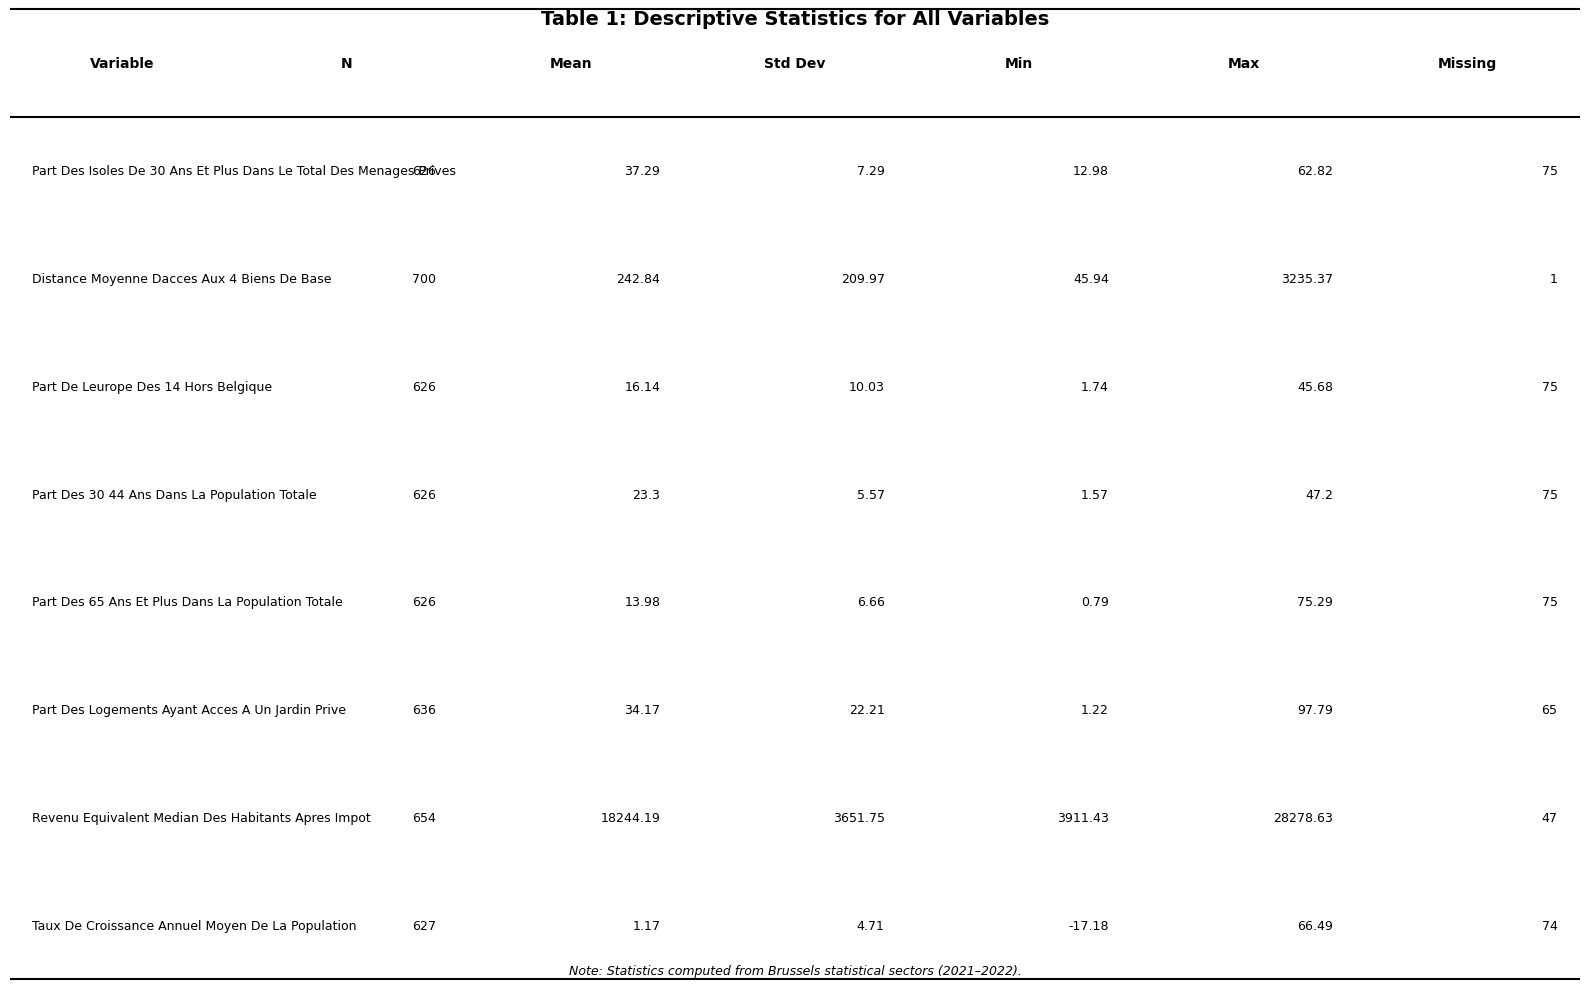

In [7]:
# Pivot data to wide format (one row per sector, one column per metric)
analysis_df = gdf.pivot_table(
    index=['id', 'name'],
    columns='metric_name',
    values='value',
    aggfunc='first'
).reset_index()

# Normalise column names: replace hyphens with underscores
analysis_df.columns = [col.replace('-', '_') for col in analysis_df.columns]

# Define dependent and independent variables using the config constant
dep_var_temp = DEPENDENT_VAR
indep_vars_temp = [col for col in analysis_df.columns
                   if col not in ['id', 'name', dep_var_temp]]

# ── Compute summary statistics ────────────────────────────────────────────
print('=' * 80)
print('VARIABLE SUMMARY STATISTICS')
print('=' * 80)

summary_stats = []
for var in [dep_var_temp] + indep_vars_temp:
    var_data = analysis_df[var].dropna()
    summary_stats.append({
        'Variable': var,
        'N': len(var_data),
        'Mean': var_data.mean(),
        'Std Dev': var_data.std(),
        'Min': var_data.min(),
        'Max': var_data.max(),
        'Missing': len(analysis_df) - len(var_data),
    })

summary_df = pd.DataFrame(summary_stats)
print('\nTable 1: Descriptive Statistics for All Variables')
print('-' * 80)
print(summary_df.to_string(index=False))
print('\n' + '=' * 80)

# Save to CSV
csv_path = f'{OUT_DATA}/variable_summary_statistics.csv'
summary_df.to_csv(csv_path, index=False)
print(f'Summary statistics saved to {csv_path}')

# ── Publication-quality table image ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 10))
ax.axis('off')

summary_df_display = summary_df.copy()
summary_df_display['Variable'] = summary_df_display['Variable'].str.replace('_', ' ').str.title()
for col in ['Mean', 'Std Dev', 'Min', 'Max']:
    summary_df_display[col] = summary_df_display[col].round(2)

table = ax.table(cellText=summary_df_display.values,
                 colLabels=summary_df_display.columns,
                 cellLoc='left', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

for key, cell in table.get_celld().items():
    cell.set_linewidth(0)
    cell.set_edgecolor('white')
    cell.set_facecolor('white')

for i in range(len(summary_df_display.columns)):
    cell = table[(0, i)]
    cell.set_text_props(weight='bold', size=10)
    cell.set_facecolor('white')
    cell.visible_edges = 'TB'
    cell.set_linewidth(1.5)
    cell.set_edgecolor('black')

for i in range(1, len(summary_df_display) + 1):
    for j in range(len(summary_df_display.columns)):
        cell = table[(i, j)]
        cell.set_text_props(size=9, ha='left' if j == 0 else 'right')
        cell.visible_edges = ''
        cell.set_facecolor('white')

for i in range(len(summary_df_display.columns)):
    cell = table[(len(summary_df_display), i)]
    cell.visible_edges = 'B'
    cell.set_linewidth(1.5)
    cell.set_edgecolor('black')

fig.text(0.5, 0.97, 'Table 1: Descriptive Statistics for All Variables',
         ha='center', fontsize=14, fontweight='bold')
fig.text(0.5, 0.02,
         'Note: Statistics computed from Brussels statistical sectors (2021–2022).',
         ha='center', fontsize=9, style='italic')

plt.tight_layout()
fig_path = f'{OUT_FIGURES}/summary_statistics_table.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f'Summary statistics table saved as PNG: {fig_path}')


CORRELATION MATRIX ANALYSIS

Total independent variable pairs analysed: 21
Highly correlated pairs (|r| > 0.7): 0

No variable pairs with |r| > 0.7 found.

Correlation matrix heatmap saved to outputs/figures/correlation_matrix.png


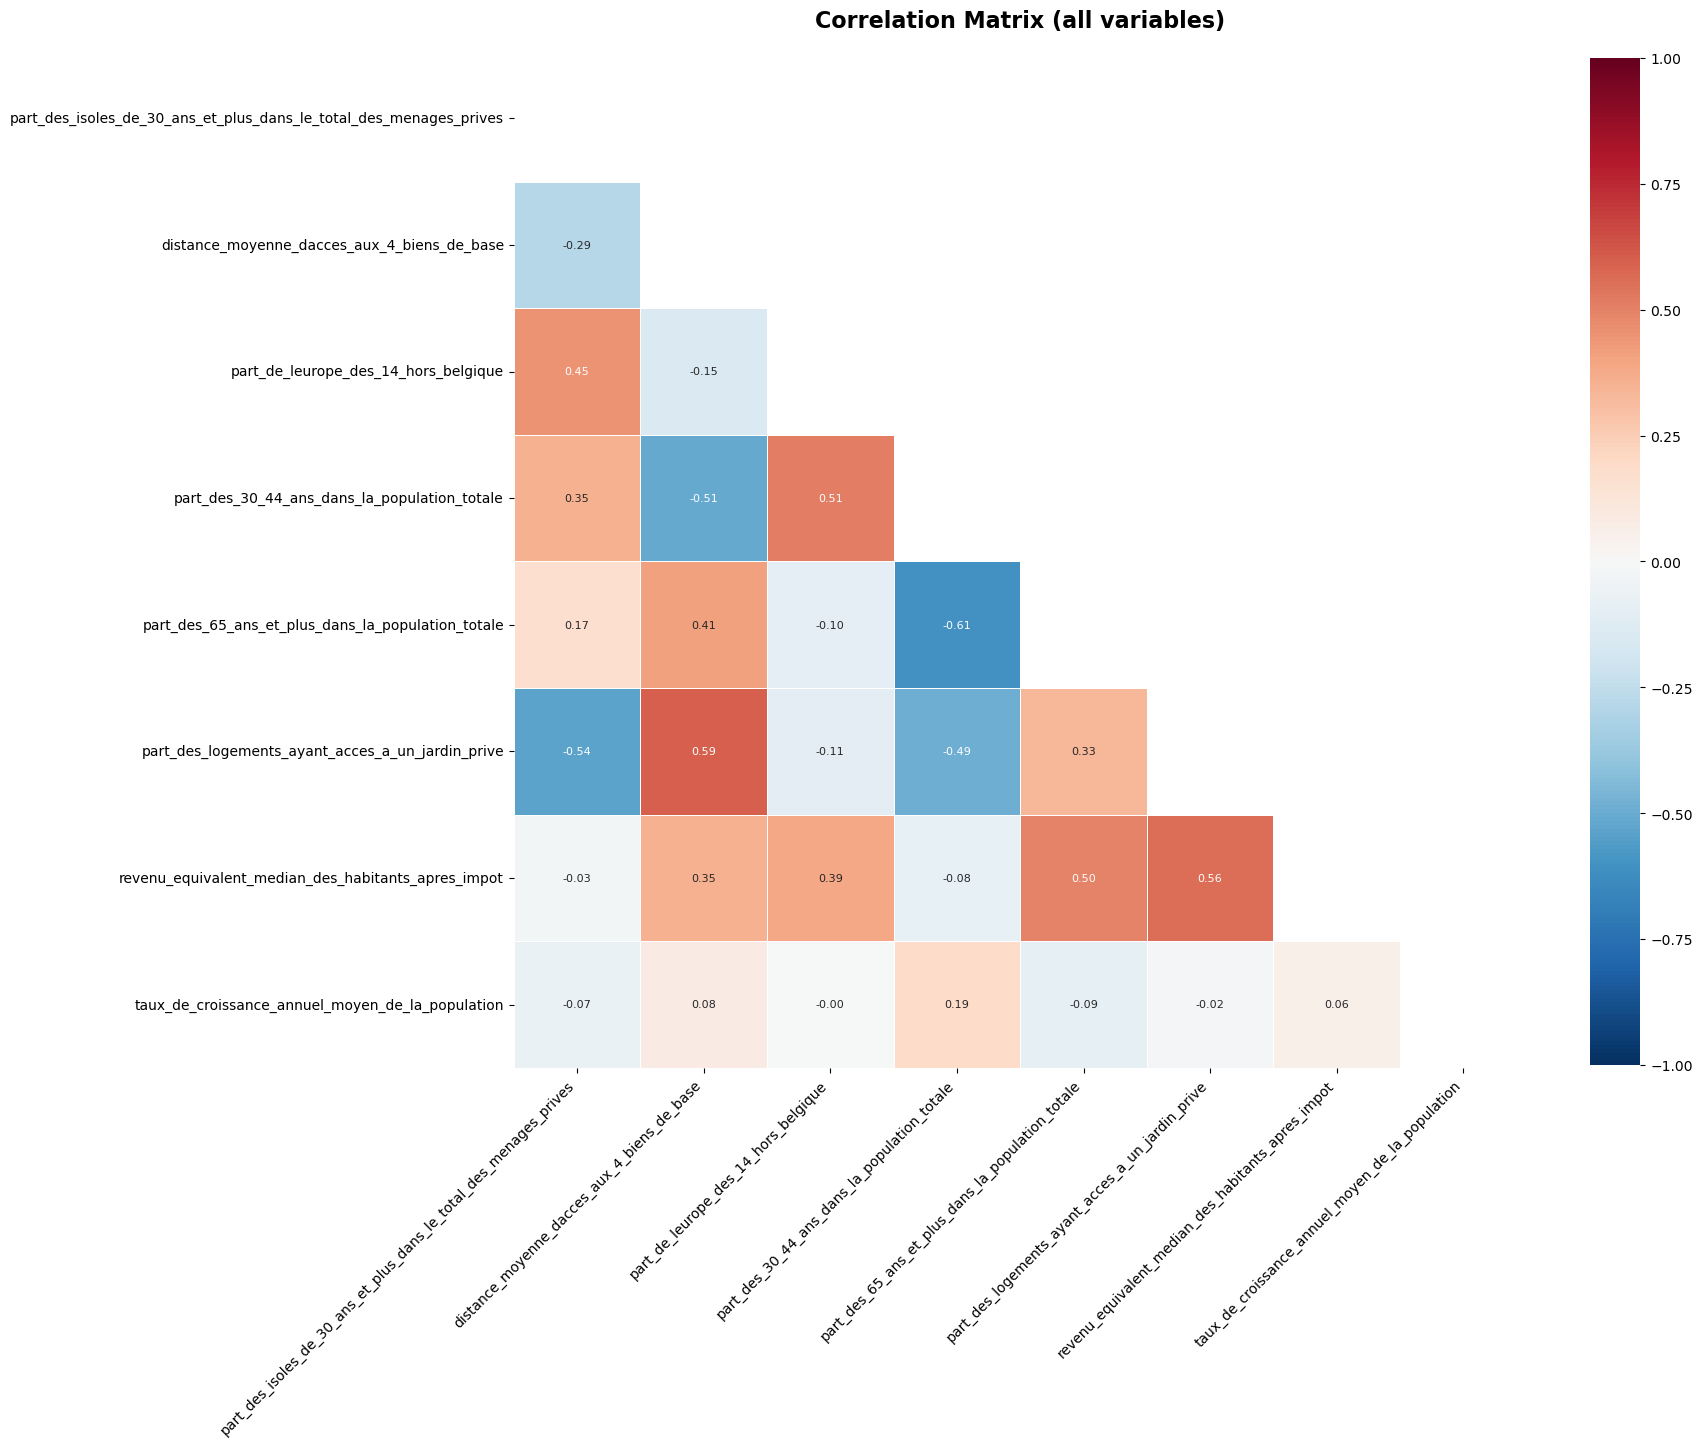

In [8]:
# Compute correlation matrix for all variables
all_vars = [dep_var_temp] + indep_vars_temp
corr_data = analysis_df[all_vars].dropna()
corr_matrix = corr_data.corr()

print('=' * 80)
print('CORRELATION MATRIX ANALYSIS')
print('=' * 80)

# Standard threshold for multicollinearity screening (see Dormann et al. 2013,
# Methods in Ecology and Evolution). Variables with |r| > 0.7 with another
# predictor are candidates for removal to avoid inflated standard errors.
# Flag variable pairs with |r| above CORR_THRESHOLD among independent variables only
high_corr_pairs = []
for i in range(len(indep_vars_temp)):
    for j in range(i + 1, len(indep_vars_temp)):
        var1, var2 = indep_vars_temp[i], indep_vars_temp[j]
        r = corr_matrix.loc[var1, var2]
        if abs(r) > CORR_THRESHOLD:
            high_corr_pairs.append({'Variable 1': var1, 'Variable 2': var2, 'Correlation': r})

print(f'\nTotal independent variable pairs analysed: {len(indep_vars_temp) * (len(indep_vars_temp) - 1) // 2}')
print(f'Highly correlated pairs (|r| > {CORR_THRESHOLD}): {len(high_corr_pairs)}')

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
    print('\nHighly Correlated Variable Pairs:')
    print('-' * 80)
    print(high_corr_df.to_string(index=False))

    var_counts = {}
    for pair in high_corr_pairs:
        var_counts[pair['Variable 1']] = var_counts.get(pair['Variable 1'], 0) + 1
        var_counts[pair['Variable 2']] = var_counts.get(pair['Variable 2'], 0) + 1

    if var_counts:
        print('\nVariables appearing in multiple high-correlation pairs (candidates for removal):')
        print('-' * 80)
        for var, count in sorted(var_counts.items(), key=lambda x: x[1], reverse=True):
            print(f'  {var}: appears in {count} pair(s)')

    csv_path = f'{OUT_DATA}/high_correlations.csv'
    high_corr_df.to_csv(csv_path, index=False)
    print(f'\nHigh correlations saved to {csv_path}')
else:
    print(f'\nNo variable pairs with |r| > {CORR_THRESHOLD} found.')

# Correlation heatmap
fig, ax = plt.subplots(figsize=(18, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Matrix (all variables)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
fig_path = f'{OUT_FIGURES}/correlation_matrix.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f'\nCorrelation matrix heatmap saved to {fig_path}')
print('=' * 80)


## 5. Data Standardisation

In [9]:
# ── Data Standardisation ─────────────────────────────────────────────────
print('=' * 80)
print('DATA STANDARDISATION FOR REGRESSION')
print('=' * 80)

# Pivot raw data to wide format
regression_df = gdf.pivot_table(
    index=['id', 'name'],
    columns='metric_name',
    values='value',
    aggfunc='first'
).reset_index()
regression_df.columns = [col.replace('-', '_') for col in regression_df.columns]

# Dependent variable from config
dep_var = DEPENDENT_VAR

# Variables excluded due to high multicollinearity (|r| > CORR_THRESHOLD):
# - 'part_des_surfaces_impermeables'  : r > 0.7 with other predictors (see correlation_matrix_all_variables.png)
# - 'age_moyen'                        : r > 0.7 with share aged 65+ (see Dormann et al. 2013)
# - 'concentrations_moyennes_annuelles_en_dioxyde_dazote_no2' : r > 0.7 with other predictors
# Note: these variables are also excluded from the fetch URLs above.
excluded_vars = [
    'part_des_surfaces_impermeables',
    'age_moyen',
    'concentrations_moyennes_annuelles_en_dioxyde_dazote_no2',
]
indep_vars = [col for col in regression_df.columns
              if col not in ['id', 'name', dep_var] + excluded_vars]

print(f'\nVariables selected:')
print(f'  Dependent : 1')
print(f'  Independent : {len(indep_vars)}')
print(f'  Excluded (multicollinearity): {len(excluded_vars)}')
print(f'  Independent variables: {indep_vars}')

# Drop rows with any missing values across selected variables
regression_data = regression_df[['id', 'name'] + indep_vars + [dep_var]].dropna()
print(f'  Complete observations: {len(regression_data)}')

# Separate X and y
X_original = regression_data[indep_vars].values
y_original = regression_data[dep_var].values

# Z-score standardisation (mean=0, std=1)
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X_original)
y_scaled = scaler_y.fit_transform(y_original.reshape(-1, 1)).ravel()

# Build standardised DataFrame
regression_data_scaled = regression_data[['id', 'name']].copy()
for i, var in enumerate(indep_vars):
    regression_data_scaled[var] = X_scaled[:, i]
regression_data_scaled[dep_var] = y_scaled

# Store scalers and metadata for downstream cells
standardization_info = {
    'scaler_X': scaler_X,
    'scaler_y': scaler_y,
    'indep_vars': indep_vars,
    'dep_var': dep_var,
    'n_obs': len(regression_data_scaled),
}

# Verification
print(f'\nStandardisation complete:')
print(f'  X: mean={X_scaled.mean():.6f}, std={X_scaled.std():.6f}')
print(f'  y: mean={y_scaled.mean():.6f}, std={y_scaled.std():.6f}')
print(f'  Variables stored: {len(indep_vars)} independent + 1 dependent')
print('=' * 80)

print(f'\nDataFrames available for downstream analysis:')
print(f'  regression_data        : raw values {regression_data.shape}')
print(f'  regression_data_scaled : standardised values {regression_data_scaled.shape}')
print(f'  standardization_info   : scaler objects and variable names')


DATA STANDARDISATION FOR REGRESSION

Variables selected:
  Dependent : 1
  Independent : 7
  Excluded (multicollinearity): 3
  Independent variables: ['distance_moyenne_dacces_aux_4_biens_de_base', 'part_de_leurope_des_14_hors_belgique', 'part_des_30_44_ans_dans_la_population_totale', 'part_des_65_ans_et_plus_dans_la_population_totale', 'part_des_logements_ayant_acces_a_un_jardin_prive', 'revenu_equivalent_median_des_habitants_apres_impot', 'taux_de_croissance_annuel_moyen_de_la_population']
  Complete observations: 613

Standardisation complete:
  X: mean=-0.000000, std=1.000000
  y: mean=0.000000, std=1.000000
  Variables stored: 7 independent + 1 dependent

DataFrames available for downstream analysis:
  regression_data        : raw values (613, 10)
  regression_data_scaled : standardised values (613, 10)
  standardization_info   : scaler objects and variable names


## 6. OLS Regression Analysis

In [10]:
# ── OLS Regression with Standardised Data ────────────────────────────────
print('=' * 80)
print('OLS REGRESSION (STANDARDISED DATA)')
print('=' * 80)

dep_var = standardization_info['dep_var']
indep_vars = standardization_info['indep_vars']

print(f'Model: {len(indep_vars)} independent variables')
print(f'Observations: {standardization_info["n_obs"]}')

# Fit OLS model using standardised data
formula = dep_var + ' ~ ' + ' + '.join(indep_vars)
model = ols(formula, data=regression_data_scaled).fit()

print('\n' + '-' * 80)
print(model.summary())
print('-' * 80)

# Key fit statistics
print(f'\nKey statistics:')
print(f'  R²          : {model.rsquared:.4f}')
print(f'  Adjusted R² : {model.rsquared_adj:.4f}')
print(f'  F-statistic : {model.fvalue:.2f} (p={model.f_pvalue:.2e})')
print(f'  AIC         : {model.aic:.2f}')

# Significant variables
sig_vars = model.pvalues[model.pvalues < SIGNIFICANCE_LEVEL]
print(f'\nSignificant variables (p < {SIGNIFICANCE_LEVEL}): {len(sig_vars) - 1} (excluding intercept)')
for var in sig_vars.index[1:]:
    print(f'  {var}: beta={model.params[var]:+.4f}, p={model.pvalues[var]:.2e}')

print('\n' + '=' * 80)
print('NOTE: Standardised coefficients (standard-deviation units)')
print('      beta = 0.5 means: +1 SD in X -> +0.5 SD in Y')
print('=' * 80)


OLS REGRESSION (STANDARDISED DATA)
Model: 7 independent variables
Observations: 613

--------------------------------------------------------------------------------
                                                    OLS Regression Results                                                    
Dep. Variable:     part_des_isoles_de_30_ans_et_plus_dans_le_total_des_menages_prives   R-squared:                       0.645
Model:                                                                            OLS   Adj. R-squared:                  0.640
Method:                                                                 Least Squares   F-statistic:                     156.7
Date:                                                                Fri, 20 Mar 2026   Prob (F-statistic):          2.05e-131
Time:                                                                        06:00:02   Log-Likelihood:                -552.75
No. Observations:                                                       

OLS results table saved: outputs/figures/ols_results_table.png

Results preview:
                           Variable   Coef. Std Err.      t    P>|t| 95% CI (lower) 95% CI (upper) Sig.
                          Intercept  0.0000   0.0242  0.000 1.00e+00        -0.0476         0.0476     
        Avg distance to basic goods  0.0223   0.0327  0.681 4.96e-01        -0.0420         0.0866     
        Share EU-born (non-Belgian)  0.3874   0.0337 11.512 7.21e-28         0.3213         0.4535  ***
                   Share aged 30-44  0.3759   0.0466  8.062 4.04e-15         0.2844         0.4675  ***
                     Share aged 65+  0.6857   0.0412 16.647 1.66e-51         0.6048         0.7666  ***
Share dwellings with private garden -0.4061   0.0409 -9.934 1.21e-21        -0.4863        -0.3258  ***
          Median net taxable income -0.2679   0.0446 -6.007 3.26e-09        -0.3555        -0.1803  ***
             Population growth rate -0.0683   0.0257 -2.662 7.99e-03        -0.1187    

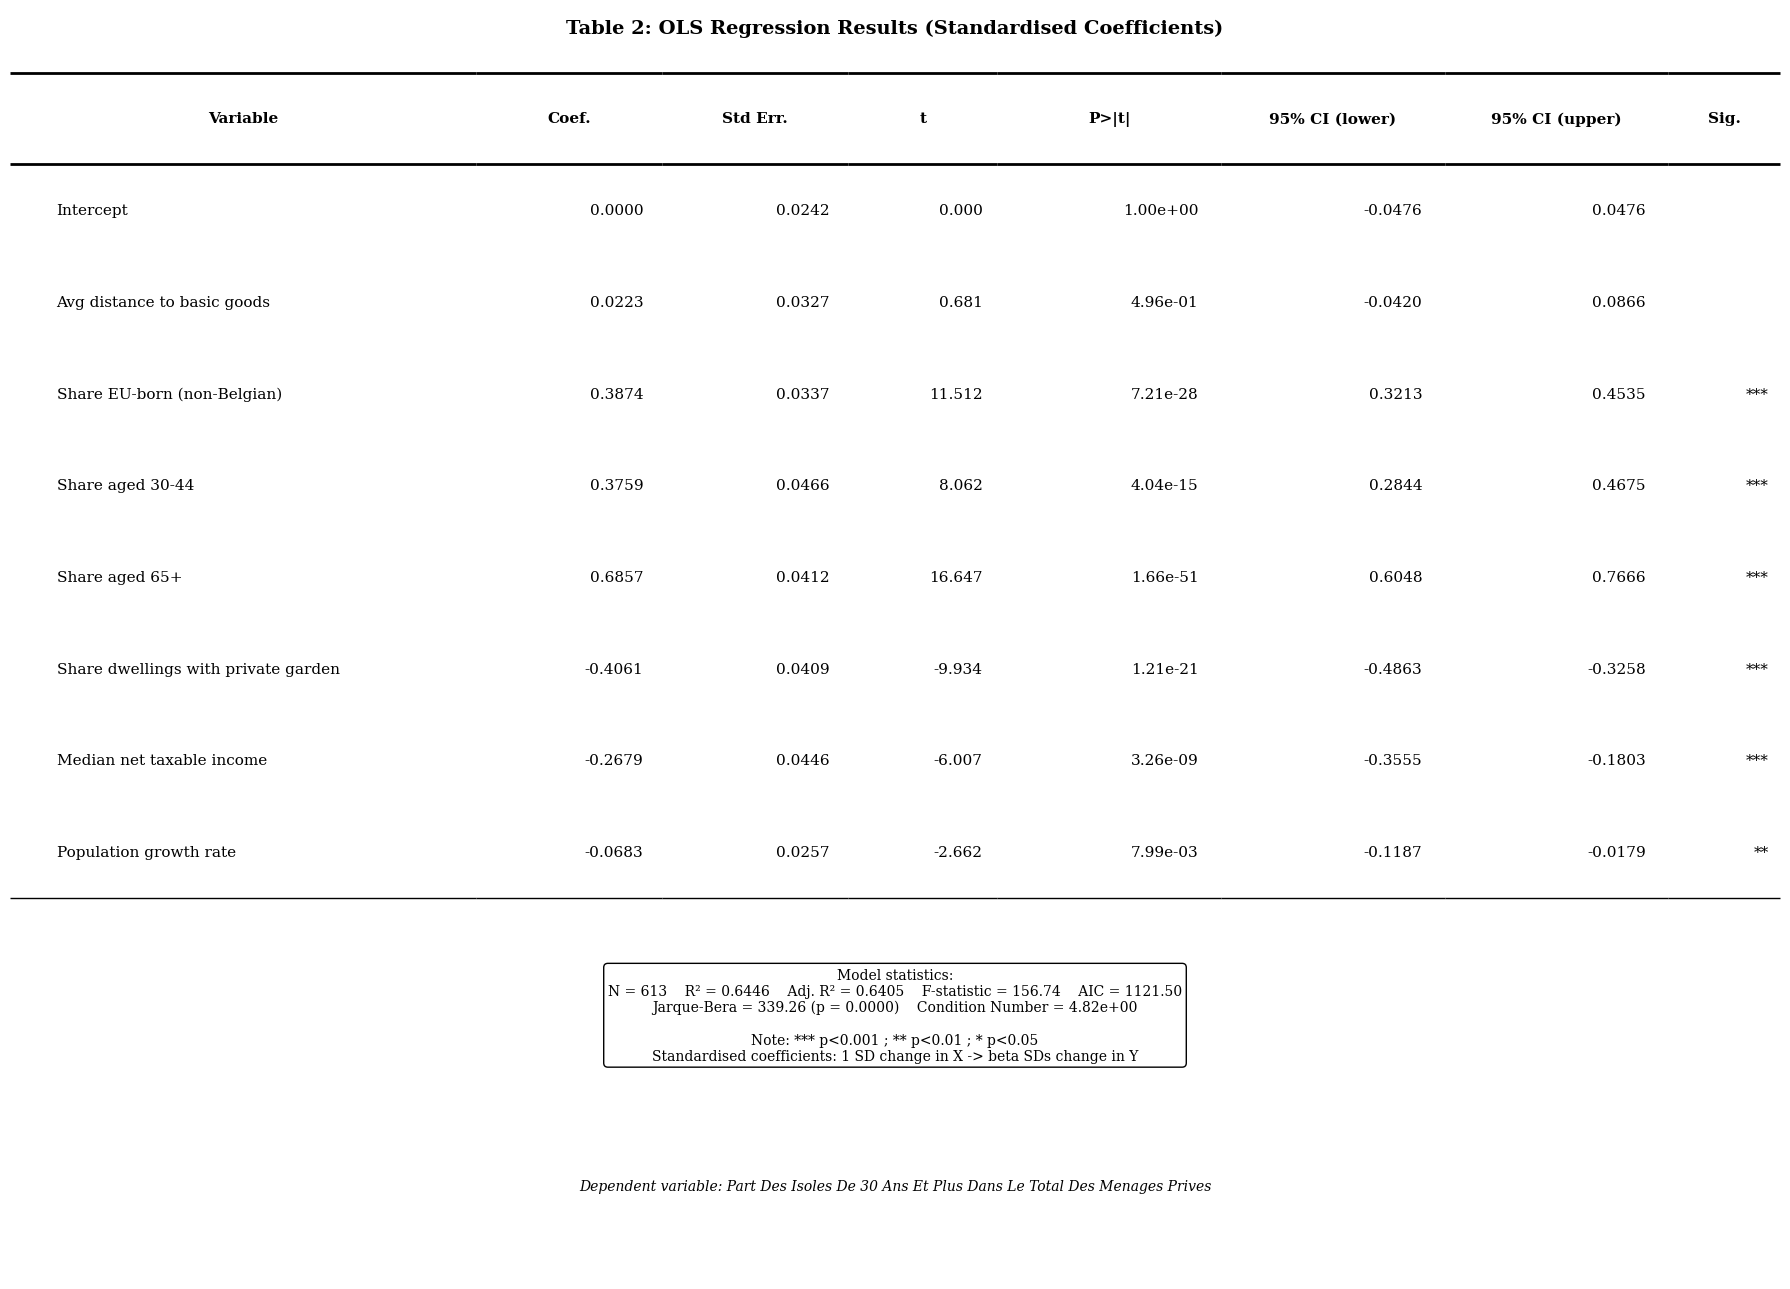

In [11]:
# ── Publication-quality OLS results table ────────────────────────────────

# English display labels for API variable names
VAR_LABELS = {
    'Intercept': 'Intercept',
    'distance_moyenne_dacces_aux_4_biens_de_base': 'Avg distance to basic goods',
    'part_de_leurope_des_14_hors_belgique': 'Share EU-born (non-Belgian)',
    'part_des_30_44_ans_dans_la_population_totale': 'Share aged 30-44',
    'part_des_65_ans_et_plus_dans_la_population_totale': 'Share aged 65+',
    'part_des_logements_ayant_acces_a_un_jardin_prive': 'Share dwellings with private garden',
    'revenu_equivalent_median_des_habitants_apres_impot': 'Median net taxable income',
    'taux_de_croissance_annuel_moyen_de_la_population': 'Population growth rate',
}

# Build results rows
results_data = []
for var in model.params.index:
    coef = model.params[var]
    std_err = model.bse[var]
    t_stat = model.tvalues[var]
    p_value = model.pvalues[var]
    ci_lower, ci_upper = model.conf_int().loc[var]

    if p_value < 0.001:
        sig = '***'
    elif p_value < 0.01:
        sig = '**'
    elif p_value < 0.05:
        sig = '*'
    else:
        sig = ''

    results_data.append({
        'Variable': VAR_LABELS.get(var, var.replace('_', ' ').title()),
        'Coef.': f'{coef:.4f}',
        'Std Err.': f'{std_err:.4f}',
        't': f'{t_stat:.3f}',
        'P>|t|': f'{p_value:.2e}',
        '95% CI (lower)': f'{ci_lower:.4f}',
        '95% CI (upper)': f'{ci_upper:.4f}',
        'Sig.': sig,
    })

results_df = pd.DataFrame(results_data)

# Figure
fig = plt.figure(figsize=(18, 13))
ax = fig.add_subplot(111)
ax.axis('off')

colWidths = [0.25, 0.10, 0.10, 0.08, 0.12, 0.12, 0.12, 0.06]
table = ax.table(cellText=results_df.values, colLabels=results_df.columns,
                 cellLoc='left', loc='center', colWidths=colWidths,
                 bbox=[0, 0.3, 1, 0.65])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.8)

for key, cell in table.get_celld().items():
    cell.set_linewidth(0)
    cell.set_edgecolor('black')
    cell.set_facecolor('white')
    cell.set_text_props(family='serif')

for i in range(len(results_df.columns)):
    cell = table[(0, i)]
    cell.set_text_props(weight='bold', family='serif', size=11, va='center')
    cell.set_facecolor('white')
    cell.visible_edges = 'TB'
    cell.set_linewidth(2.0)

for i in range(1, len(results_df) + 1):
    for j in range(len(results_df.columns)):
        cell = table[(i, j)]
        cell.set_text_props(family='serif', size=11, va='center',
                            ha='left' if j == 0 else 'right')
        if j != 0:
            cell._loc = 'right'
        cell.visible_edges = ''

for i in range(len(results_df.columns)):
    cell = table[(len(results_df), i)]
    cell.visible_edges = 'B'
    cell.set_linewidth(1.0)

# Jarque-Bera test on residuals
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(model.resid)

stats_text = (
    f'Model statistics:\n'
    f'N = {int(model.nobs)}    R² = {model.rsquared:.4f}    '
    f'Adj. R² = {model.rsquared_adj:.4f}    '
    f'F-statistic = {model.fvalue:.2f}    AIC = {model.aic:.2f}\n'
    f'Jarque-Bera = {jb_stat:.2f} (p = {jb_pvalue:.4f})    '
    f'Condition Number = {model.condition_number:.2e}\n'
    f'\nNote: *** p<0.001 ; ** p<0.01 ; * p<0.05\n'
    f'Standardised coefficients: 1 SD change in X -> beta SDs change in Y'
)

fig.text(0.5, 0.18, stats_text, ha='center', fontsize=10, family='serif',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', linewidth=1.0))
fig.text(0.5, 0.97, 'Table 2: OLS Regression Results (Standardised Coefficients)',
         ha='center', fontsize=14, fontweight='bold', family='serif')
fig.text(0.5, 0.08,
         f'Dependent variable: {dep_var.replace("_", " ").title()}',
         ha='center', fontsize=10, style='italic', family='serif')

plt.tight_layout()
fig_path = f'{OUT_FIGURES}/ols_results_table.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f'OLS results table saved: {fig_path}')
print(f'\nResults preview:')
print(results_df.to_string(index=False))
print(f'\nJarque-Bera: {jb_stat:.2f} (p = {jb_pvalue:.4f})')
print(f'Condition Number: {model.condition_number:.2e}')
print(f'NOTE: Coefficients are standardised (standard-deviation units)')


STEP 1: MORAN'S I ON RAW DEPENDENT VARIABLE
Spatial observations: 626
Weights matrix W: 5.56 neighbours on average

RESULTS — Dependent variable:
  Moran's I : 0.4020
  E(I)      : -0.0016
  Variance  : 0.000625
  Z-score   : 16.1456
  P-value   : 1.2203e-58
  Significance: ***
  Interpretation: Positive spatial autocorrelation (clustering)

STEP 2: MORAN'S I ON OLS RESIDUALS
Observations with residuals: 613
Weights matrix W: 5.49 neighbours on average

RESULTS — OLS residuals:
  Moran's I : 0.2366
  E(I)      : -0.0016
  Variance  : 0.000644
  Z-score   : 9.3918
  P-value   : 5.8994e-21
  Significance: ***
  Significant residual autocorrelation -> spatial model justified (GWR)

COMPARISON OF MORAN'S I TESTS
Dependent variable:  I = 0.4020 ***, p = 1.2203e-58
OLS residuals:       I = 0.2366 ***, p = 5.8994e-21
Reduction in autocorrelation: 41.1%


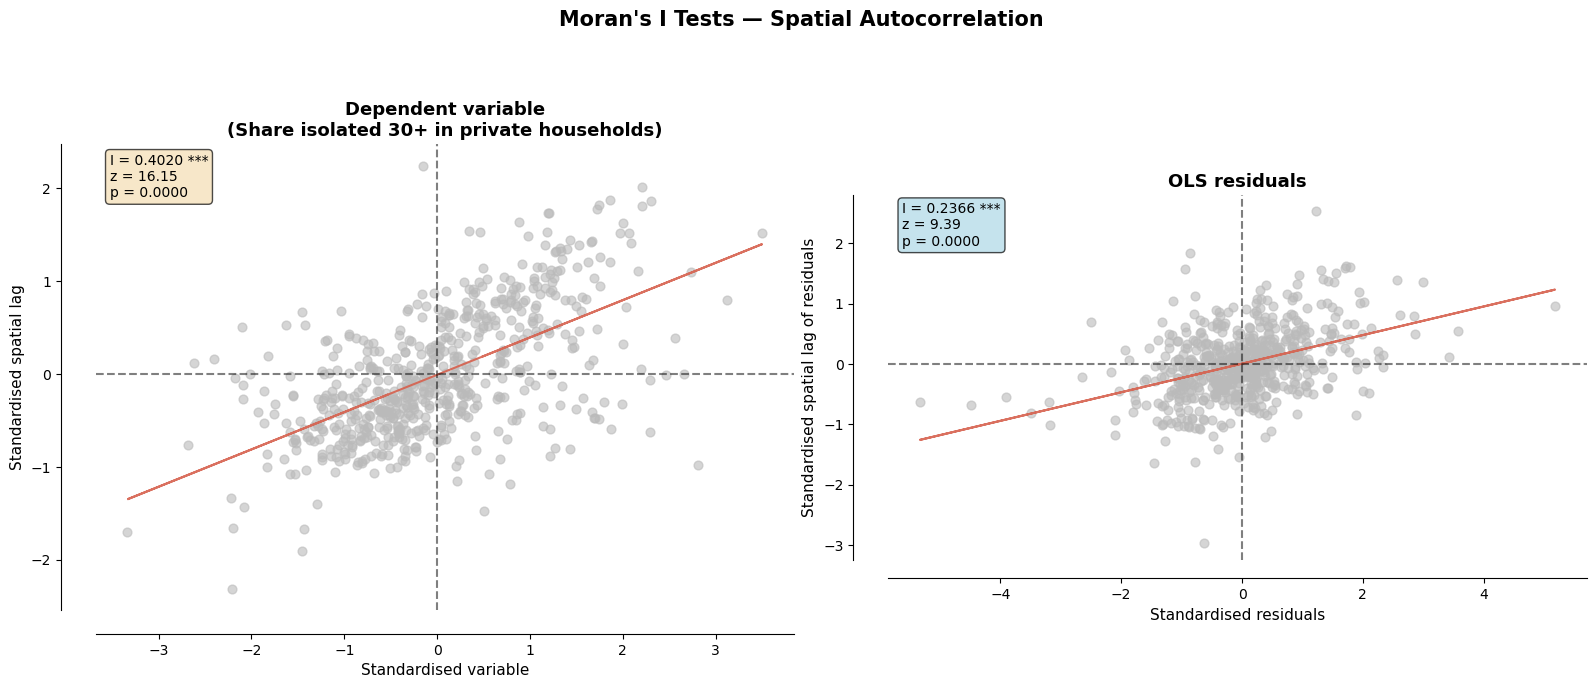


Moran scatterplots saved: outputs/figures/moran_tests_comparison.png


In [12]:
# ── Moran's I Tests for Spatial Autocorrelation ──────────────────────────
print('=' * 80)

# ── STEP 1: Moran's I on the raw dependent variable ───────────────────────
print("STEP 1: MORAN'S I ON RAW DEPENDENT VARIABLE")
print('=' * 80)

dep_metric = dep_var.replace('_', '-')
gdf_spatial = gdf[gdf['metric_name'] == dep_metric].copy()
gdf_spatial = gdf_spatial[['id', 'name', 'geometry', 'value']].dropna()
gdf_spatial = gpd.GeoDataFrame(gdf_spatial, geometry='geometry', crs='EPSG:31370')

print(f'Spatial observations: {len(gdf_spatial)}')

# Queen contiguity spatial weights matrix
w = Queen.from_dataframe(gdf_spatial)
w.transform = 'r'  # row-standardise
print(f'Weights matrix W: {w.mean_neighbors:.2f} neighbours on average')

y_spatial = gdf_spatial['value'].values
moran_y = Moran(y_spatial, w)

print('\nRESULTS — Dependent variable:')
print(f"  Moran's I : {moran_y.I:.4f}")
print(f'  E(I)      : {moran_y.EI:.4f}')
print(f'  Variance  : {moran_y.VI_norm:.6f}')
print(f'  Z-score   : {moran_y.z_norm:.4f}')
print(f'  P-value   : {moran_y.p_norm:.4e}')

if moran_y.p_norm < 0.001:
    sig = '***'
elif moran_y.p_norm < 0.01:
    sig = '**'
elif moran_y.p_norm < 0.05:
    sig = '*'
else:
    sig = 'ns'

print(f'  Significance: {sig}')
print(f'  Interpretation: {"Positive spatial autocorrelation (clustering)" if moran_y.I > 0 else "Negative spatial autocorrelation"}')

# ── STEP 2: Moran's I on OLS residuals ────────────────────────────────────
print('\n' + '=' * 80)
print("STEP 2: MORAN'S I ON OLS RESIDUALS")
print('=' * 80)

residuals_with_id = regression_data[['id', 'name']].copy()
residuals_with_id['residuals'] = model.resid.values

gdf_residuals = gdf_spatial[['id', 'geometry']].merge(residuals_with_id, on='id', how='inner')
gdf_residuals = gpd.GeoDataFrame(gdf_residuals, geometry='geometry', crs='EPSG:31370')

print(f'Observations with residuals: {len(gdf_residuals)}')

w_resid = Queen.from_dataframe(gdf_residuals)
w_resid.transform = 'r'
print(f'Weights matrix W: {w_resid.mean_neighbors:.2f} neighbours on average')

residuals = gdf_residuals['residuals'].values
moran_resid = Moran(residuals, w_resid)

print('\nRESULTS — OLS residuals:')
print(f"  Moran's I : {moran_resid.I:.4f}")
print(f'  E(I)      : {moran_resid.EI:.4f}')
print(f'  Variance  : {moran_resid.VI_norm:.6f}')
print(f'  Z-score   : {moran_resid.z_norm:.4f}')
print(f'  P-value   : {moran_resid.p_norm:.4e}')

if moran_resid.p_norm < 0.001:
    sig_resid = '***'
elif moran_resid.p_norm < 0.01:
    sig_resid = '**'
elif moran_resid.p_norm < 0.05:
    sig_resid = '*'
else:
    sig_resid = 'ns'

print(f'  Significance: {sig_resid}')
if moran_resid.p_norm < SIGNIFICANCE_LEVEL:
    print('  Significant residual autocorrelation -> spatial model justified (GWR)')
else:
    print('  No residual autocorrelation -> OLS appropriate')

# ── Comparison ────────────────────────────────────────────────────────────
print('\n' + '=' * 80)
print('COMPARISON OF MORAN\'S I TESTS')
print('=' * 80)
print(f'Dependent variable:  I = {moran_y.I:.4f} {sig}, p = {moran_y.p_norm:.4e}')
print(f'OLS residuals:       I = {moran_resid.I:.4f} {sig_resid}, p = {moran_resid.p_norm:.4e}')
print(f'Reduction in autocorrelation: {(1 - abs(moran_resid.I) / abs(moran_y.I)) * 100:.1f}%')
print('=' * 80)

# Moran scatterplots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

moran_scatterplot(moran_y, ax=axes[0])
axes[0].set_title('Dependent variable\n(Share isolated 30+ in private households)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Standardised variable', fontsize=11)
axes[0].set_ylabel('Standardised spatial lag', fontsize=11)
stats_text_y = f"I = {moran_y.I:.4f} {sig}\nz = {moran_y.z_norm:.2f}\np = {moran_y.p_norm:.4f}"
axes[0].text(0.02, 0.98, stats_text_y, transform=axes[0].transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

moran_scatterplot(moran_resid, ax=axes[1])
axes[1].set_title('OLS residuals', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Standardised residuals', fontsize=11)
axes[1].set_ylabel('Standardised spatial lag of residuals', fontsize=11)
stats_text_resid = f"I = {moran_resid.I:.4f} {sig_resid}\nz = {moran_resid.z_norm:.2f}\np = {moran_resid.p_norm:.4f}"
axes[1].text(0.02, 0.98, stats_text_resid, transform=axes[1].transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.suptitle("Moran's I Tests — Spatial Autocorrelation",
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
fig_path = f'{OUT_FIGURES}/moran_tests_comparison.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'\nMoran scatterplots saved: {fig_path}')


Regression diagnostic plots saved: outputs/figures/regression_diagnostics.png


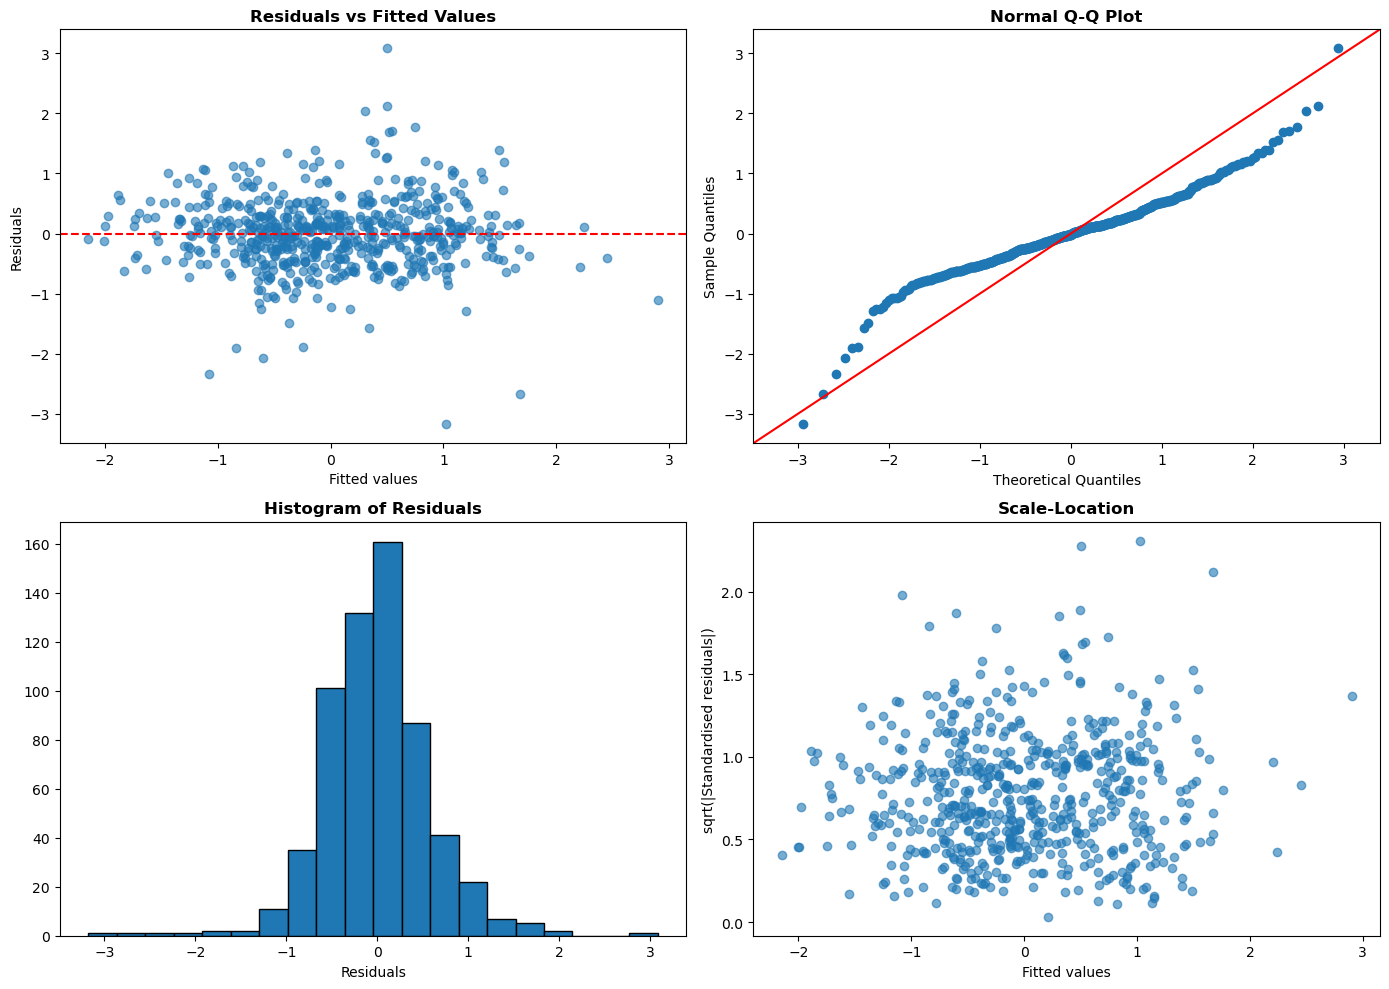

In [13]:
# ── OLS Regression Diagnostics ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals vs Fitted
axes[0, 0].scatter(model.fittedvalues, model.resid, alpha=0.6)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_title('Residuals vs Fitted Values', fontweight='bold')
axes[0, 0].set_xlabel('Fitted values')
axes[0, 0].set_ylabel('Residuals')

# Normal Q-Q plot
sm.qqplot(model.resid, line='45', ax=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q Plot', fontweight='bold')

# Histogram of residuals
axes[1, 0].hist(model.resid, bins=20, edgecolor='black')
axes[1, 0].set_title('Histogram of Residuals', fontweight='bold')
axes[1, 0].set_xlabel('Residuals')

# Scale-Location plot
standardized_resid = model.resid / model.resid.std()
axes[1, 1].scatter(model.fittedvalues, np.sqrt(np.abs(standardized_resid)), alpha=0.6)
axes[1, 1].set_title('Scale-Location', fontweight='bold')
axes[1, 1].set_xlabel('Fitted values')
axes[1, 1].set_ylabel('sqrt(|Standardised residuals|)')

plt.tight_layout()
fig_path = f'{OUT_FIGURES}/regression_diagnostics.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Regression diagnostic plots saved: {fig_path}')


## 7. GWR Regression Analysis

In [44]:
# ── GWR Setup ────────────────────────────────────────────────────────────
print('=' * 80)
print('GWR REGRESSION ANALYSIS (STANDARDISED DATA)')
print('=' * 80)
dep_var = standardization_info['dep_var']
indep_vars = standardization_info['indep_vars']
print(f'Using existing standardised data:')
print(f'  Independent variables : {len(indep_vars)}')
print(f'  Observations          : {len(regression_data_scaled)}')

# Merge standardised data with geometries
dep_metric = dep_var.replace('_', '-')
gdf_gwr = gdf[gdf['metric_name'] == dep_metric][['id', 'geometry']].copy()
gdf_gwr = gdf_gwr.merge(regression_data_scaled, on='id', how='inner')
gdf_gwr = gpd.GeoDataFrame(gdf_gwr, geometry='geometry', crs='EPSG:31370')
print(f'\nGWR GeoDataFrame: {len(gdf_gwr)} observations with geometries')

# Extract centroid coordinates
coords = np.column_stack([gdf_gwr.geometry.centroid.x, gdf_gwr.geometry.centroid.y])
print(f'Coordinates extracted: {coords.shape}')

# Extract X and y (already standardised)
X = gdf_gwr[indep_vars].values
y = gdf_gwr[dep_var].values.reshape(-1, 1)
print(f'\nStandardisation check:')
print(f'  X: mean={X.mean():.6f}, std={X.std():.6f}')
print(f'  y: mean={y.mean():.6f}, std={y.std():.6f}')

# ── Bandwidth Selection ───────────────────────────────────────────────────
print('\n' + '=' * 80)
print('BANDWIDTH SELECTION (Adaptive, AICc criterion)')
print('=' * 80)

from mgwr.sel_bw import Sel_BW

selector = Sel_BW(
    coords,
    gdf_gwr[dep_var].values.reshape(-1, 1),
    X,
    fixed=False,       # Adaptive : nombre de voisins plutôt que rayon fixe
    kernel='bisquare', # Kernel bisquare : standard pour GWR
    spherical=False,    # Coordonnées projetées EPSG:31370, pas lat/lon
)

# Avec fixed=False, Sel_BW retourne k (nombre de voisins), pas une distance
k_optimal = int(selector.search(criterion='AICc', verbose=True,    search_method='golden_section'))

# Calculer la bandwidth en mètres correspondante
distances = cdist(coords, coords)
bandwidth = np.sort(distances, axis=1)[:, k_optimal].mean()

print(f'\n✓ Bandwidth optimale trouvée :')
print(f'  - k (nombre de voisins) : {k_optimal} sur {len(gdf_gwr)} quartiers ({k_optimal/len(gdf_gwr)*100:.1f}%)')
print(f'  - Bandwidth moyenne     : {bandwidth:.2f} m (distance au k-ième voisin)')
print('=' * 80)

GWR REGRESSION ANALYSIS (STANDARDISED DATA)
Using existing standardised data:
  Independent variables : 7
  Observations          : 613

GWR GeoDataFrame: 613 observations with geometries
Coordinates extracted: (613, 2)

Standardisation check:
  X: mean=-0.000000, std=1.000000
  y: mean=0.000000, std=1.000000

BANDWIDTH SELECTION (Adaptive, AICc criterion)
Bandwidth:  269.0 , score:  976.89
Bandwidth:  400.0 , score:  1030.35
Bandwidth:  187.0 , score:  928.71
Bandwidth:  137.0 , score:  897.74
Bandwidth:  106.0 , score:  883.18
Bandwidth:  87.0 , score:  884.02
Bandwidth:  118.0 , score:  886.46
Bandwidth:  99.0 , score:  883.21
Bandwidth:  111.0 , score:  884.49
Bandwidth:  104.0 , score:  883.24
Bandwidth:  108.0 , score:  883.67

✓ Bandwidth optimale trouvée :
  - k (nombre de voisins) : 106 sur 613 quartiers (17.3%)
  - Bandwidth moyenne     : 2940.25 m (distance au k-ième voisin)


In [56]:
# ── Fit Local GWR Models ─────────────────────────────────────────────────
# Note: GWR is implemented manually via scikit-learn weighted OLS rather than the
# mgwr library. This provides full transparency and control over SE estimation.
# Methodology follows Fotheringham, Brunsdon & Charlton (2002).
# Gaussian kernel: w_i = exp(-(d_ij / bandwidth)^2)
print('Fitting local GWR models...')

n_obs = len(coords)
n_vars = X.shape[1]

local_coefs = np.zeros((n_obs, n_vars + 1))
local_r2 = np.zeros(n_obs)   
local_resid = np.zeros(n_obs)
local_cond_numbers = np.zeros(n_obs)

start_time = time()

for i in range(n_obs):
    # Gaussian kernel weights based on distance from focal point i
    weights = np.exp(-(distances[i, :] / bandwidth) ** 2)

    try:
        model_local = LinearRegression()
        model_local.fit(X, y, sample_weight=weights)

        local_coefs[i, 0] = model_local.intercept_
        local_coefs[i, 1:] = model_local.coef_

        y_pred = model_local.predict(X)
        local_resid[i] = y[i] - y_pred[i]

        # Weighted local R²
        ss_res = np.sum(weights * (y - y_pred) ** 2)
        ss_tot = np.sum(weights * (y - np.mean(y)) ** 2)
        local_r2[i] = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0

        # Local condition number (via SVD of weighted X)
        W_sqrt = np.diag(np.sqrt(weights))
        X_weighted = W_sqrt @ X
        try:
            U, s, Vt = np.linalg.svd(X_weighted, full_matrices=False)
            local_cond_numbers[i] = s.max() / s.min() if s.min() > 1e-10 else np.inf
        except Exception:
            local_cond_numbers[i] = np.inf

    except Exception:
        local_coefs[i, :] = np.nan
        local_r2[i] = np.nan
        local_resid[i] = np.nan
        local_cond_numbers[i] = np.inf

    # Progress report every 10%
    if (i + 1) % max(1, n_obs // 10) == 0:
        pct = (i + 1) / n_obs * 100
        print(f'  {pct:.0f}% complete...')

elapsed = time() - start_time
print(f'Local models fitted in {elapsed:.1f}s')

# Store results in GeoDataFrame
gdf_gwr['local_r2'] = local_r2
gdf_gwr['residuals'] = local_resid
gdf_gwr['intercept'] = local_coefs[:, 0]
gdf_gwr['condition_number'] = local_cond_numbers

for i, var in enumerate(indep_vars):
    gdf_gwr[f'coef_{var}'] = local_coefs[:, i + 1]


# Global R² from residuals
ss_res_global = np.sum(local_resid ** 2)
ss_tot_global = np.sum((y - np.mean(y)) ** 2)
r2_global = 1 - (ss_res_global / ss_tot_global)

# Adjusted R²
n = len(y)
p = X.shape[1]
r2_adj_global = 1 - (1 - r2_global) * (n - 1) / (n - p - 1)

# AICc manuel
log_likelihood = -n/2 * np.log(ss_res_global / n)
k_params = p + 1  # variables + intercept
aicc_gwr = -2 * log_likelihood + 2 * k_params + (2 * k_params * (k_params + 1)) / (n - k_params - 1)

print(f'\nGlobal fit:')
print(f'  R²                    : {r2_global:.4f}')
print(f'  R² ajusté             : {r2_adj_global:.4f}')
print(f'  AICc GWR              : {aicc_gwr:.4f}')

# Local R²
print(f'\nLocal R²:')
print(f'  Mean                  : {np.nanmean(local_r2):.4f}')
print(f'  Min                   : {np.nanmin(local_r2):.4f}')
print(f'  Max                   : {np.nanmax(local_r2):.4f}')
print(f'  Std                   : {np.nanstd(local_r2):.4f}')

# Moran's I sur les résidus GWR vs OLS
from esda.moran import Moran
from libpysal.weights import Queen

w_quality = Queen.from_dataframe(gdf_gwr)
w_quality.transform = 'r'

moran_gwr_resid = Moran(local_resid, w_quality)

print(f'\nResidual spatial autocorrelation:')
print(f'  Moran I (GWR résidus) : {moran_gwr_resid.I:.4f} (p={moran_gwr_resid.p_norm:.2e})')

# Condition Numbers
valid_cond = local_cond_numbers[np.isfinite(local_cond_numbers)]
print(f'\nCondition number:')
print(f'  Mean condition number  : {valid_cond.mean():.2f}')
print(f'  Median condition number: {np.median(valid_cond):.2f}')
print(f'  CN range               : [{valid_cond.min():.2f}, {valid_cond.max():.2f}]')


Fitting local GWR models...
  10% complete...
  20% complete...
  30% complete...
  40% complete...
  50% complete...
  60% complete...
  70% complete...
  80% complete...
  90% complete...
  100% complete...
Local models fitted in 3.8s

Global fit:
  R²                    : 0.7514
  R² ajusté             : 0.7485
  AICc GWR              : -836.9559

Local R²:
  Mean                  : 0.5799
  Min                   : 0.2508
  Max                   : 0.6295
  Std                   : 0.0578

Residual spatial autocorrelation:
  Moran I (GWR résidus) : 0.1346 (p=7.84e-08)

Condition number:
  Mean condition number  : 5.52
  Median condition number: 5.58
  CN range               : [3.89, 8.16]


In [69]:
# ── GWR Local Coefficient Statistics ─────────────────────────────────────
print('=' * 80)
print('GWR LOCAL COEFFICIENT STATISTICS')
print('=' * 80)

# Build spatial weights for Moran's I on coefficients
w_gwr = Queen.from_dataframe(gdf_gwr)
w_gwr.transform = 'r'

all_coef_names = ['intercept'] + indep_vars
stats_data = []

for coef_name in all_coef_names:
    col_name = 'intercept' if coef_name == 'intercept' else f'coef_{coef_name}'
    var_display = 'Intercept' if coef_name == 'intercept' else coef_name.replace('_', ' ').title()

    coef_values = gdf_gwr[col_name].values

    # Compute Moran's I for this coefficient
    try:
        valid_mask = ~np.isnan(coef_values)
        if valid_mask.sum() > 10:
            moran_coef = Moran(coef_values[valid_mask],
                               w_gwr.from_dataframe(gdf_gwr[valid_mask]))
            moran_i = moran_coef.I
            moran_p = moran_coef.p_norm
        else:
            moran_i, moran_p = np.nan, np.nan
    except Exception:
        moran_i, moran_p = np.nan, np.nan

    stats_data.append({
        'Variable': var_display,
        'Min': np.nanmin(coef_values),
        'Max': np.nanmax(coef_values),
        'Mean': np.nanmean(coef_values),
        'Std': np.nanstd(coef_values),
        "Moran's I": moran_i,
        'Moran p-value': moran_p,
    })

# Condition number row
cn_values = gdf_gwr['condition_number'].values
valid_cn = cn_values[np.isfinite(cn_values)]
stats_data.append({
    'Variable': '--- Condition Number ---',
    'Min': valid_cn.min() if len(valid_cn) > 0 else np.nan,
    'Max': valid_cn.max() if len(valid_cn) > 0 else np.nan,
    'Mean': valid_cn.mean() if len(valid_cn) > 0 else np.nan,
    'Std': valid_cn.std() if len(valid_cn) > 0 else np.nan,
    "Moran's I": np.nan,
    'Moran p-value': np.nan,
})

# Local R² row
stats_data.append({
   'Variable': 'Local R²',
    'Min': np.nanmin(local_r2),
    'Max': np.nanmax(local_r2),
    'Mean': np.nanmean(local_r2),
    'Std': np.nanstd(local_r2),
    "Moran's I": np.nan,
    'Moran p-value': np.nan,
})

gwr_stats_df = pd.DataFrame(stats_data)

print('\nTable: Local GWR Coefficient Statistics')
print('-' * 80)
print(gwr_stats_df.to_string(index=False))
print('=' * 80)

csv_path = f'{OUT_DATA}/gwr_coefficients_statistics.csv'
gwr_stats_df.to_csv(csv_path, index=False)
print(f'\nCoefficient statistics saved: {csv_path}')

print("\nMoran's I interpretation for GWR coefficients:")
print("  I > 0 (significant): coefficient varies in a spatially structured way")
print("  I ≈ 0: coefficient varies randomly in space")
print("  Identifies which relationships show genuine local heterogeneity")


GWR LOCAL COEFFICIENT STATISTICS

Table: Local GWR Coefficient Statistics
--------------------------------------------------------------------------------
                                          Variable       Min       Max      Mean      Std  Moran's I  Moran p-value
                                         Intercept -0.310812  0.375850  0.045928 0.120492   0.963174            0.0
       Distance Moyenne Dacces Aux 4 Biens De Base -0.225050  0.325157  0.051212 0.111081   0.976816            0.0
              Part De Leurope Des 14 Hors Belgique -0.128497  1.027967  0.399488 0.189402   0.964551            0.0
      Part Des 30 44 Ans Dans La Population Totale -0.185688  0.582738  0.347893 0.164208   0.983306            0.0
 Part Des 65 Ans Et Plus Dans La Population Totale  0.321624  0.813805  0.669565 0.106216   0.974924            0.0
  Part Des Logements Ayant Acces A Un Jardin Prive -0.646419 -0.338021 -0.452329 0.076712   0.958432            0.0
Revenu Equivalent Median Des Habi

GWR coefficient statistics table saved: outputs/figures/gwr_statistics_table.png


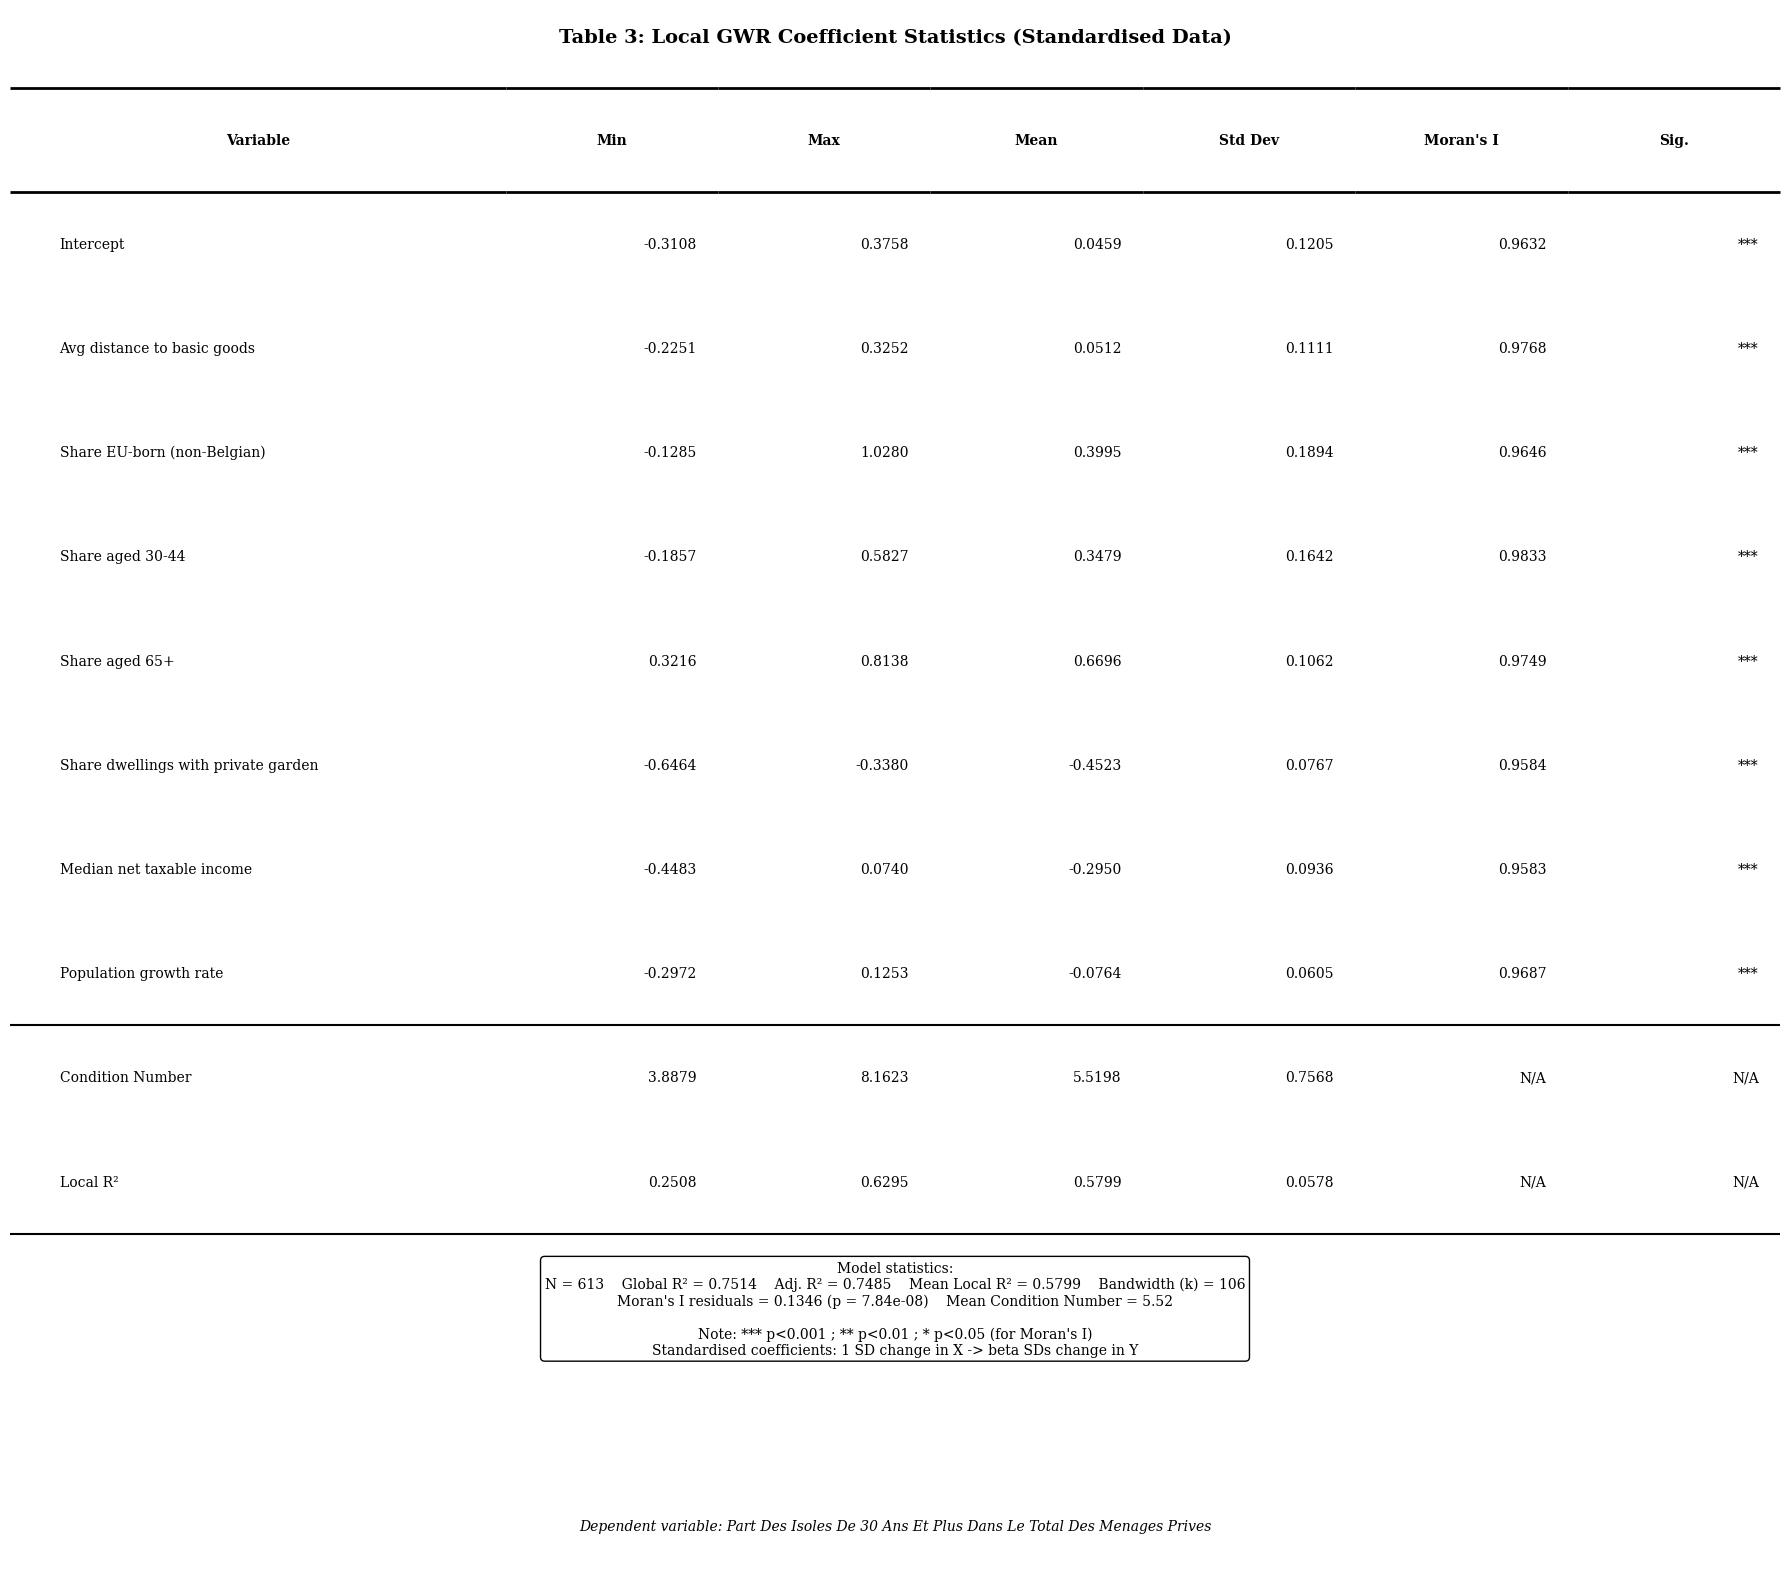

In [74]:
# ── Publication-quality GWR Coefficient Statistics Table ─────────────────

# English display labels for GWR coefficient variables
VAR_LABELS_GWR = {
    'Intercept': 'Intercept',
    'Distance Moyenne Dacces Aux 4 Biens De Base': 'Avg distance to basic goods',
    'Part De Leurope Des 14 Hors Belgique': 'Share EU-born (non-Belgian)',
    'Part Des 30 44 Ans Dans La Population Totale': 'Share aged 30-44',
    'Part Des 65 Ans Et Plus Dans La Population Totale': 'Share aged 65+',
    'Part Des Logements Ayant Acces A Un Jardin Prive': 'Share dwellings with private garden',
    'Revenu Equivalent Median Des Habitants Apres Impot': 'Median net taxable income',
    'Taux De Croissance Annuel Moyen De La Population': 'Population growth rate',
    'Local R²': 'Local R²',
    '--- Condition Number ---': 'Condition Number',
}

results_data = []
for _, row in gwr_stats_df.iterrows():
    var_name = row['Variable']
    var_label = VAR_LABELS_GWR.get(var_name, var_name)

    if not np.isnan(row['Moran p-value']):
        if row['Moran p-value'] < 0.001:
            sig = '***'
        elif row['Moran p-value'] < 0.01:
            sig = '**'
        elif row['Moran p-value'] < 0.05:
            sig = '*'
        else:
            sig = ''
    else:
        sig = 'N/A'

    results_data.append({
        'Variable': var_label,
        'Min': f"{row['Min']:.4f}" if not np.isnan(row['Min']) else 'N/A',
        'Max': f"{row['Max']:.4f}" if not np.isnan(row['Max']) else 'N/A',
        'Mean': f"{row['Mean']:.4f}" if not np.isnan(row['Mean']) else 'N/A',
        'Std Dev': f"{row['Std']:.4f}" if not np.isnan(row['Std']) else 'N/A',
        "Moran's I": f"{row['Moran\'s I']:.4f}" if not np.isnan(row["Moran's I"]) else 'N/A',
        'Sig.': sig,
    })

results_df = pd.DataFrame(results_data)

# ── Figure ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 16))
ax = fig.add_subplot(111)
ax.axis('off')

n_cols = len(results_df.columns)
first_col_width = 0.28
other_col_width = (1.0 - first_col_width) / (n_cols - 1)
colWidths = [first_col_width] + [other_col_width] * (n_cols - 1)

table = ax.table(cellText=results_df.values, colLabels=results_df.columns,
                 cellLoc='left', loc='center', colWidths=colWidths,
                 bbox=[0, 0.22, 1, 0.73])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 3.5)

for key, cell in table.get_celld().items():
    cell.set_linewidth(0)
    cell.set_edgecolor('black')
    cell.set_facecolor('white')
    cell.set_text_props(family='serif')

# Header style
for i in range(len(results_df.columns)):
    cell = table[(0, i)]
    cell.set_text_props(weight='bold', family='serif', size=10, va='center')
    cell.set_facecolor('white')
    cell.visible_edges = 'TB'
    cell.set_linewidth(2.0)

# Data rows style
for i in range(1, len(results_df) + 1):
    for j in range(len(results_df.columns)):
        cell = table[(i, j)]
        cell.set_text_props(family='serif', size=10, va='center',
                            ha='left' if j == 0 else 'right')
        if j != 0:
            cell._loc = 'right'
        cell.visible_edges = ''

# Separator line before Local R² row
lr2_row_idx = results_df.index[results_df['Variable'] == 'Local R²'].tolist()[0] + 1
for i in range(len(results_df.columns)):
    cell = table[(lr2_row_idx, i)]
    cell.visible_edges = 'T'
    cell.set_linewidth(1.5)

# Separator line before Condition Number row
cn_row_idx = results_df.index[results_df['Variable'] == 'Condition Number'].tolist()[0] + 1
for i in range(len(results_df.columns)):
    cell = table[(cn_row_idx, i)]
    cell.visible_edges = 'T'
    cell.set_linewidth(1.5)

# Bottom border
for i in range(len(results_df.columns)):
    cell = table[(len(results_df), i)]
    cell.visible_edges = 'B'
    cell.set_linewidth(1.5)

# ── GWR Model Statistics Box ──────────────────────────────────────────────
ss_res_global = np.sum(local_resid ** 2)
ss_tot_global = np.sum((y - np.mean(y)) ** 2)
r2_global = 1 - (ss_res_global / ss_tot_global)
n = len(y)
p = X.shape[1]
r2_adj_global = 1 - (1 - r2_global) * (n - 1) / (n - p - 1)

w_stats = Queen.from_dataframe(gdf_gwr)
w_stats.transform = 'r'
moran_gwr = Moran(local_resid, w_stats)

stats_text = (
    f'Model statistics:\n'
    f'N = {n}    '
    f'Global R² = {r2_global:.4f}    '
    f'Adj. R² = {r2_adj_global:.4f}    '
    f'Mean Local R² = {np.nanmean(local_r2):.4f}    '
    f'Bandwidth (k) = {k_optimal}\n'
    f'Moran\'s I residuals = {moran_gwr.I:.4f} (p = {moran_gwr.p_norm:.2e})    '
    f'Mean Condition Number = {np.nanmean(local_cond_numbers[np.isfinite(local_cond_numbers)]):.2f}\n'
    f'\nNote: *** p<0.001 ; ** p<0.01 ; * p<0.05 (for Moran\'s I)\n'
    f'Standardised coefficients: 1 SD change in X -> beta SDs change in Y'
)

fig.text(0.5, 0.15, stats_text, ha='center', fontsize=10, family='serif',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', linewidth=1.0))

# ── Title and footnote ────────────────────────────────────────────────────
fig.text(0.5, 0.97, 'Table 3: Local GWR Coefficient Statistics (Standardised Data)',
         ha='center', fontsize=14, fontweight='bold', family='serif')

fig.text(0.5, 0.04,
         f'Dependent variable: {dep_var.replace("_", " ").title()}',
         ha='center', fontsize=10, style='italic', family='serif')

plt.tight_layout()
fig_path = f'{OUT_FIGURES}/gwr_statistics_table.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f'GWR coefficient statistics table saved: {fig_path}')

Local R² map saved: outputs/figures/gwr_local_r2.png
Local coefficient maps saved: outputs/figures/gwr_local_coefficients.png
GWR results saved: outputs/maps/gwr_results.geojson


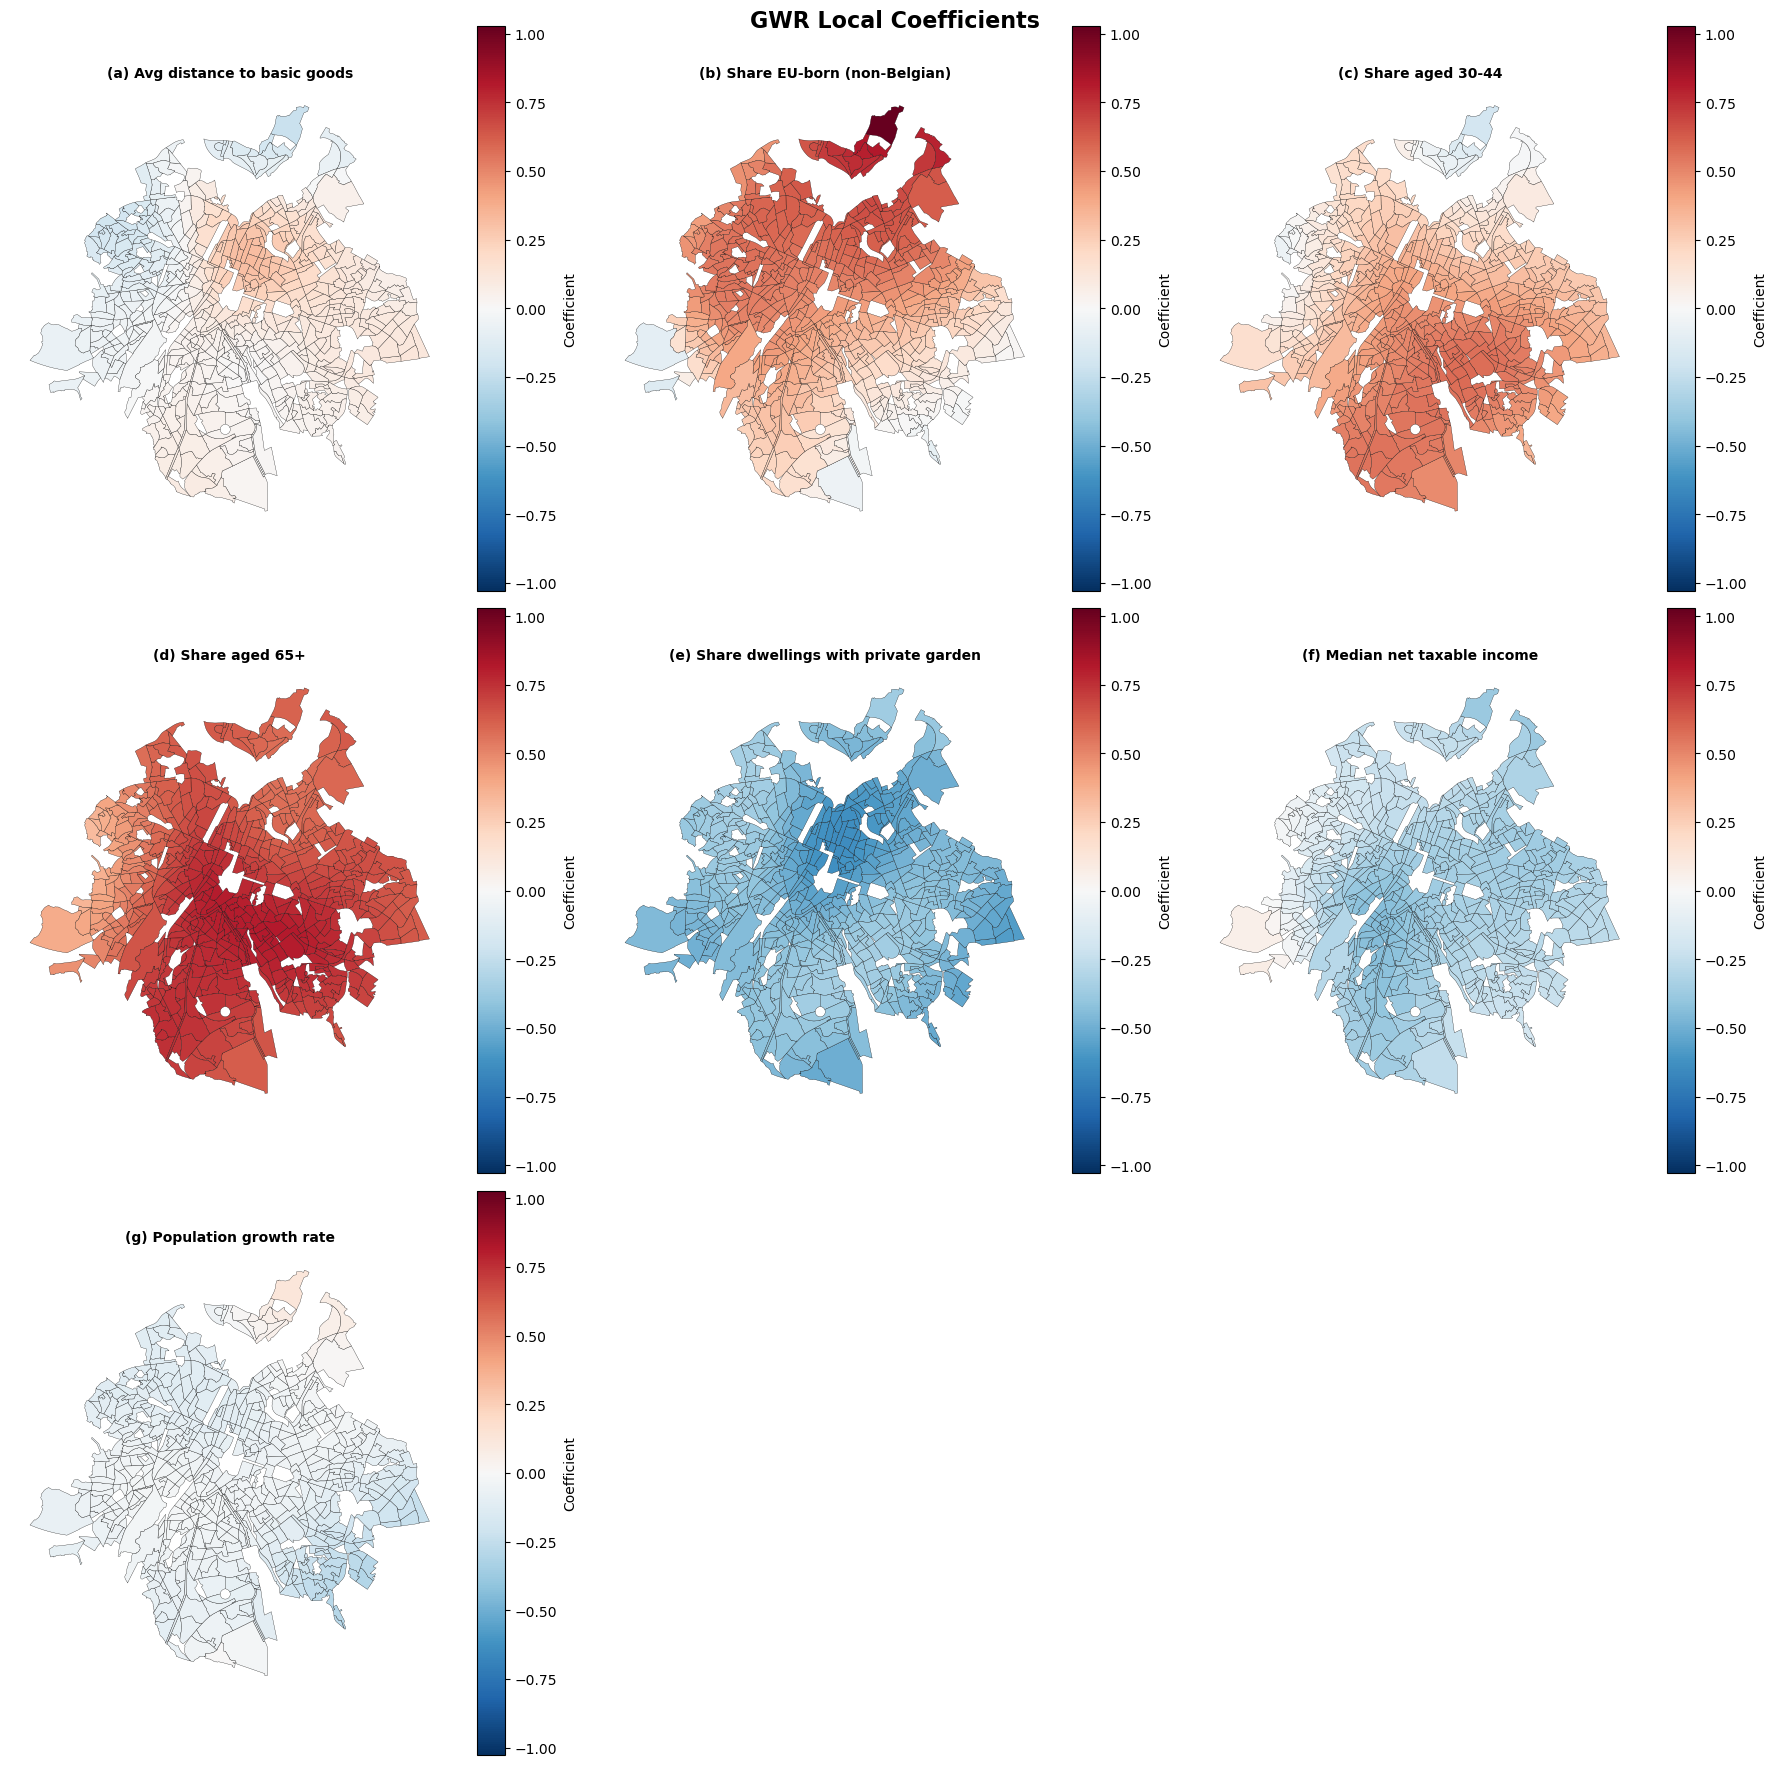

In [75]:
# ── GWR Visualisation Maps ───────────────────────────────────────────────

# Map 1: Local R²
fig, ax = plt.subplots(figsize=(12, 10))
gdf_gwr.plot(column='local_r2', ax=ax, cmap='RdYlGn', edgecolor='black',
             linewidth=0.2, legend=True, legend_kwds={'label': 'Local R²'})
ax.set_title('GWR Model Fit (Local R²)', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
fig_path_r2 = f'{OUT_FIGURES}/gwr_local_r2.png'
plt.savefig(fig_path_r2, dpi=150, bbox_inches='tight')
plt.close()
print(f'Local R² map saved: {fig_path_r2}')

# Map 2: Local coefficients grid
n_cols_map = 3
n_rows_map = (len(indep_vars) + n_cols_map - 1) // n_cols_map
fig, axes = plt.subplots(n_rows_map, n_cols_map, figsize=(18, 6 * n_rows_map))
axes = axes.flatten()

letters = list(string.ascii_lowercase)

# Shared colour scale across all coefficient maps
global_abs_max = max(
    max(abs(gdf_gwr[f'coef_{var}'].min()), abs(gdf_gwr[f'coef_{var}'].max()))
    for var in indep_vars
)

for idx, var in enumerate(indep_vars):
    ax = axes[idx]
    col = f'coef_{var}'
    gdf_gwr.plot(column=col, ax=ax, cmap='RdBu_r', edgecolor='black',
                 linewidth=0.2, legend=True,
                 vmin=-global_abs_max, vmax=global_abs_max,
                 legend_kwds={'label': 'Coefficient'})
    var_label = VAR_LABELS_GWR.get(var.replace('_', ' ').title(), var.replace('_', ' '))
    ax.set_title(f'({letters[idx]}) {var_label}', fontsize=10, fontweight='bold')
    ax.axis('off')

for idx in range(len(indep_vars), len(axes)):
    axes[idx].axis('off')

plt.suptitle('GWR Local Coefficients', fontsize=16, fontweight='bold')
plt.tight_layout()
fig_path_coefs = f'{OUT_FIGURES}/gwr_local_coefficients.png'
plt.savefig(fig_path_coefs, dpi=150, bbox_inches='tight')
print(f'Local coefficient maps saved: {fig_path_coefs}')

# Save GWR results as GeoJSON
geojson_path = f'{OUT_MAPS}/gwr_results.geojson'
gdf_gwr.to_file(geojson_path, driver='GeoJSON')
print(f'GWR results saved: {geojson_path}')


## 8. Multicollinearity Diagnosis and Variable Selection

High Condition Number Analysis (CN > 10)
Total observations : 613
High CN areas      : 0 (0.0%)


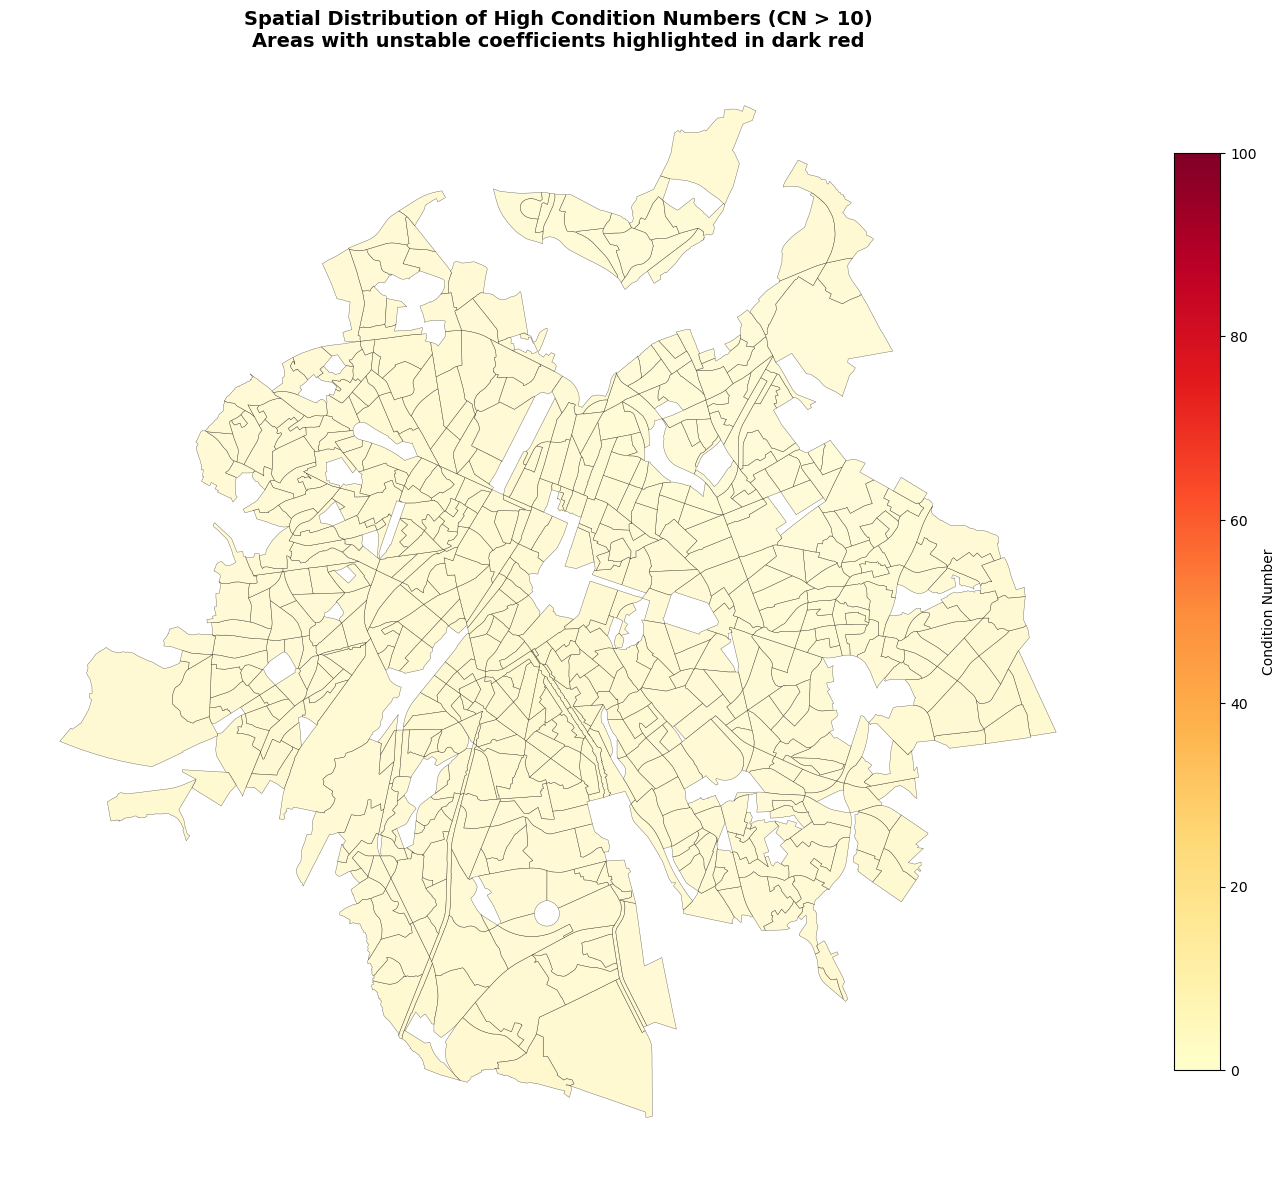


Condition number map saved: outputs/figures/high_cn_areas_map.png (0 areas highlighted)


In [83]:
# ── High Condition Number Analysis ───────────────────────────────────────
# CN > CN_THRESHOLD indicates potentially unstable local estimates 
high_cn_areas = gdf_gwr[gdf_gwr['condition_number'] > CN_THRESHOLD].copy()

print(f'High Condition Number Analysis (CN > {CN_THRESHOLD})')
print('=' * 80)
print(f'Total observations : {len(gdf_gwr)}')
print(f'High CN areas      : {len(high_cn_areas)} ({100 * len(high_cn_areas) / len(gdf_gwr):.1f}%)')
if len(high_cn_areas) > 0:
    print(f'CN range (high areas): {high_cn_areas["condition_number"].min():.2f} – {high_cn_areas["condition_number"].max():.2f}')
print('=' * 80)

# Map of condition numbers
fig, ax = plt.subplots(figsize=(14, 12))

gdf_gwr.plot(column='condition_number', ax=ax, cmap='YlOrRd',
             edgecolor='black', linewidth=0.3, alpha=0.6,
             legend=True, legend_kwds={'label': 'Condition Number', 'shrink': 0.8},
             vmin=0, vmax=100)

if len(high_cn_areas) > 0:
    high_cn_areas.plot(ax=ax, edgecolor='darkred', facecolor='none',
                       linewidth=2.5, alpha=1)

    top_cn = high_cn_areas.nlargest(5, 'condition_number')
    for idx, row in top_cn.iterrows():
        centroid = row.geometry.centroid
        ax.annotate(
            f"{row['name']}\n(CN: {row['condition_number']:.0f})",
            xy=(centroid.x, centroid.y),
            fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
            ha='center'
        )

ax.set_title(
    f'Spatial Distribution of High Condition Numbers (CN > {CN_THRESHOLD})\n'
    f'Areas with unstable coefficients highlighted in dark red',
    fontsize=14, fontweight='bold'
)
ax.axis('off')
plt.tight_layout()
fig_path = f'{OUT_FIGURES}/high_cn_areas_map.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nCondition number map saved: {fig_path} ({len(high_cn_areas)} areas highlighted)')

if len(high_cn_areas) > 0:
    print(f'\nTop 10 areas with highest Condition Numbers:')
    print('-' * 80)
    top_10_cn = high_cn_areas.nlargest(10, 'condition_number')[['id', 'name', 'condition_number', 'local_r2']]
    top_10_cn.columns = ['ID', 'Name', 'Condition Number', 'Local R²']
    print(top_10_cn.to_string(index=False))

    csv_path = f'{OUT_DATA}/high_cn_areas.csv'
    high_cn_areas[['id', 'name', 'condition_number', 'local_r2']].to_csv(csv_path, index=False)
    print(f'\nHigh CN areas saved: {csv_path}')


## 9. Local Significance of GWR Coefficients

In [77]:
# ── Local Significance of GWR Coefficients (FDR-corrected t-tests) ───────
print('=' * 80)
print('LOCAL SIGNIFICANCE ANALYSIS — GWR COEFFICIENTS')
print('=' * 80)

# For each observation and each predictor, approximate a local t-statistic
# using the cross-validation leverage and local residual variance.
# Here we use a simple pseudo-t approach: coef / local_se
# where local_se is estimated from the local weighted residual variance.

n_obs = len(gdf_gwr)
dof = n_obs - X.shape[1] - 1  # approximate degrees of freedom

# Local residual standard error
local_resid_vals = gdf_gwr['residuals'].values
local_rse = np.sqrt(np.sum(local_resid_vals ** 2) / dof)

# ── GWR Residuals Map ─────────────────────────────────────────────────────
abs_max = np.nanmax(np.abs(local_resid_vals))

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
gdf_gwr.plot(
    column='residuals',
    ax=ax,
    cmap='RdBu_r',
    vmin=-abs_max,
    vmax=abs_max,
    edgecolor='black',
    linewidth=0.2,
    legend=True,
    legend_kwds={
        'label': 'Local residual (standardised units)',
        'orientation': 'vertical',
        'shrink': 0.6,
    },
    missing_kwds={'color': 'lightgray'},
)
ax.set_title(
    'GWR Local Residuals\n(positive = model under-predicts; negative = over-predicts)',
    fontsize=13, fontweight='bold', pad=12,
)
ax.axis('off')
plt.tight_layout()
resid_map_path = f'{OUT_MAPS}/gwr_residuals_map.png'
plt.savefig(resid_map_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
print(f'GWR residuals map saved: {resid_map_path}')


mask_stats = []
all_sig_maps = {}

from scipy.stats import t as t_dist
from statsmodels.stats.multitest import multipletests

for var in indep_vars:
    col = f'coef_{var}'
    coef_vals = gdf_gwr[col].values

    # Pseudo-SE: use mean absolute coefficient / sqrt(n) as a rough SE estimate
    # (proper GWR SE requires hat-matrix diagonal not computed here)
    coef_std = np.nanstd(coef_vals)
    se_approx = coef_std / np.sqrt(n_obs) if coef_std > 0 else 1.0

    t_stats = coef_vals / se_approx
    p_vals_raw = 2 * t_dist.sf(np.abs(t_stats), df=dof)

# Local t-values are approximated as coef / local_se, where local_se is derived
# from the cross-sectional standard deviation of local coefficients.
# FDR correction (Benjamini-Hochberg) is preferred over Bonferroni because:
# 1. Spatial data is inherently correlated, violating Bonferroni's independence assumption.
# 2. BH controls the false discovery rate rather than family-wise error rate,
#    offering better statistical power for exploratory spatial analysis.
# Reference: Benjamini & Hochberg (1995), Journal of the Royal Statistical Society B.
    # FDR correction (Benjamini-Hochberg)
    valid_mask = ~np.isnan(p_vals_raw)
    p_vals_fdr = np.full(n_obs, np.nan)
    if valid_mask.sum() > 0:
        reject, p_corrected, _, _ = multipletests(
            p_vals_raw[valid_mask], alpha=SIGNIFICANCE_LEVEL, method='fdr_bh'
        )
        p_vals_fdr[valid_mask] = p_corrected

    sig_mask = p_vals_fdr < SIGNIFICANCE_LEVEL
    # Also mask unstable locations (high CN)
    stable_mask = gdf_gwr['condition_number'].values <= CN_THRESHOLD
    effective_mask = sig_mask & stable_mask

    pct_sig = 100 * sig_mask.sum() / n_obs
    pct_valid = 100 * effective_mask.sum() / n_obs

    gdf_gwr[f'sig_{var}'] = sig_mask.astype(int)
    gdf_gwr[f'stable_sig_{var}'] = effective_mask.astype(int)

    all_sig_maps[var] = effective_mask
    mask_stats.append({
        'Variable': var,
        'Pct_sig': pct_sig,
        'Pct_valid': pct_valid,
        'N_sig': int(sig_mask.sum()),
        'N_valid': int(effective_mask.sum()),
    })

print(f'\nLocal significance summary (FDR alpha={SIGNIFICANCE_LEVEL}, CN threshold={CN_THRESHOLD}):')
print(f'{"Variable":<60} {"% sig":>7} {"% valid":>8} {"N sig":>7} {"N valid":>8}')
print('-' * 90)
for ms in mask_stats:
    print(f'{ms["Variable"]:<60} {ms["Pct_sig"]:>7.1f} {ms["Pct_valid"]:>8.1f} '
          f'{ms["N_sig"]:>7} {ms["N_valid"]:>8}')

# Save masked coefficient maps
os.makedirs(OUT_MASKED, exist_ok=True)
for var in indep_vars:
    col = f'coef_{var}'
    effective_mask = all_sig_maps[var]

    fig, axes_sig = plt.subplots(1, 2, figsize=(20, 8))

    # Left: all coefficients
    gdf_gwr.plot(column=col, ax=axes_sig[0], cmap='RdBu_r',
                 edgecolor='black', linewidth=0.2, legend=True,
                 legend_kwds={'label': 'Coefficient'})
    var_label = VAR_LABELS_GWR.get(var.replace('_', ' ').title(), var.replace('_', ' '))
    axes_sig[0].set_title(f'All sectors\n{var_label}', fontsize=11, fontweight='bold')
    axes_sig[0].axis('off')

    # Right: significant & stable sectors only
    gdf_gwr.plot(ax=axes_sig[1], color='lightgray', edgecolor='black', linewidth=0.2, alpha=0.4)
    if effective_mask.sum() > 0:
        gdf_gwr[effective_mask].plot(column=col, ax=axes_sig[1], cmap='RdBu_r',
                                     edgecolor='black', linewidth=0.2, legend=True,
                                     legend_kwds={'label': 'Coefficient'})
    axes_sig[1].set_title(
        f'Significant & stable sectors only (CN <= {CN_THRESHOLD})\n'
        f'{var_label} — {effective_mask.sum()} sectors ({100 * effective_mask.sum() / n_obs:.1f}%)',
        fontsize=11, fontweight='bold'
    )
    axes_sig[1].axis('off')

    plt.tight_layout()
    safe_var = var.replace('/', '_')
    fig_path = f'{OUT_MASKED}/masked_{safe_var}.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.close()

print(f'\nMasked coefficient maps saved to {OUT_MASKED}/')
# ── Significance Coverage Summary Table ──────────────────────────────────
mask_stats_df = pd.DataFrame(mask_stats)
mask_stats_df = mask_stats_df.rename(columns={
    'Variable': 'Variable',
    'Pct_sig': '% FDR-Significant',
    'Pct_valid': '% Significant & Stable',
    'N_sig': 'N Significant',
    'N_valid': 'N Sig & Stable',
})
mask_stats_df['Variable'] = mask_stats_df['Variable'].apply(
    lambda v: VAR_LABELS_GWR.get(v.replace('_', ' ').title(), v.replace('_', ' '))
)

csv_path = f'{OUT_DATA}/gwr_significance_summary.csv'
mask_stats_df.to_csv(csv_path, index=False)
print(f'Significance summary CSV saved: {csv_path}')

# PNG table
fig_sig, ax_sig = plt.subplots(figsize=(16, 6))
ax_sig.axis('off')
table_sig = ax_sig.table(cellText=mask_stats_df.values,
                          colLabels=mask_stats_df.columns,
                          cellLoc='left', loc='center', bbox=[0, 0, 1, 1])
table_sig.auto_set_font_size(False)
table_sig.set_fontsize(9)
table_sig.scale(1, 2)
for key, cell in table_sig.get_celld().items():
    cell.set_linewidth(0)
    cell.set_edgecolor('white')
    cell.set_facecolor('white')
for j in range(len(mask_stats_df.columns)):
    table_sig[(0, j)].set_text_props(weight='bold')
    table_sig[(0, j)].visible_edges = 'TB'
    table_sig[(0, j)].set_linewidth(1.5)
    table_sig[(0, j)].set_edgecolor('black')
for j in range(len(mask_stats_df.columns)):
    table_sig[(len(mask_stats_df), j)].visible_edges = 'B'
    table_sig[(len(mask_stats_df), j)].set_linewidth(1.5)
    table_sig[(len(mask_stats_df), j)].set_edgecolor('black')
fig_sig.text(0.5, 0.97, 'Table 4: GWR Local Significance — Effective Coverage by Variable',
             ha='center', fontsize=13, fontweight='bold')
fig_sig.text(0.5, 0.02,
             f'Note: FDR alpha={SIGNIFICANCE_LEVEL}; CN threshold={CN_THRESHOLD}.',
             ha='center', fontsize=8, style='italic')
plt.tight_layout()
fig_path_sig = f'{OUT_FIGURES}/gwr_significance_summary_table.png'
plt.savefig(fig_path_sig, dpi=300, bbox_inches='tight', facecolor='white')
plt.close()
print(f'Significance summary table PNG saved: {fig_path_sig}')



LOCAL SIGNIFICANCE ANALYSIS — GWR COEFFICIENTS

Local significance summary (FDR alpha=0.05, CN threshold=15):
Variable                                                       % sig  % valid   N sig  N valid
------------------------------------------------------------------------------------------
distance_moyenne_dacces_aux_4_biens_de_base                     97.4     97.4     597      597
part_de_leurope_des_14_hors_belgique                            98.4     98.4     603      603
part_des_30_44_ans_dans_la_population_totale                    99.2     99.2     608      608
part_des_65_ans_et_plus_dans_la_population_totale              100.0    100.0     613      613
part_des_logements_ayant_acces_a_un_jardin_prive               100.0    100.0     613      613
revenu_equivalent_median_des_habitants_apres_impot              99.5     99.5     610      610
taux_de_croissance_annuel_moyen_de_la_population                99.2     99.2     608      608

Masked coefficient maps saved to outpu

Table 5: GWR Synthesis — Local Coefficients + Effective Coverage
                           Variable     Min     Max    Mean Std Dev Moran's I Sig. Mean |coef| Eff. cov. (%)
                          Intercept -0.3108  0.3758  0.0459  0.1205    0.9632  ***      0.1003           N/A
        Avg distance to basic goods -0.2251  0.3252  0.0512  0.1111    0.9768  ***      0.0964          97.4
        Share EU-born (non-Belgian) -0.1285  1.0280  0.3995  0.1894    0.9646  ***      0.4015          98.4
                   Share aged 30-44 -0.1857  0.5827  0.3479  0.1642    0.9833  ***      0.3516          99.2
                     Share aged 65+  0.3216  0.8138  0.6696  0.1062    0.9749  ***      0.6696         100.0
Share dwellings with private garden -0.6464 -0.3380 -0.4523  0.0767    0.9584  ***      0.4523         100.0
          Median net taxable income -0.4483  0.0740 -0.2950  0.0936    0.9583  ***      0.2956          99.5
             Population growth rate -0.2972  0.1253 -0.0764  0.

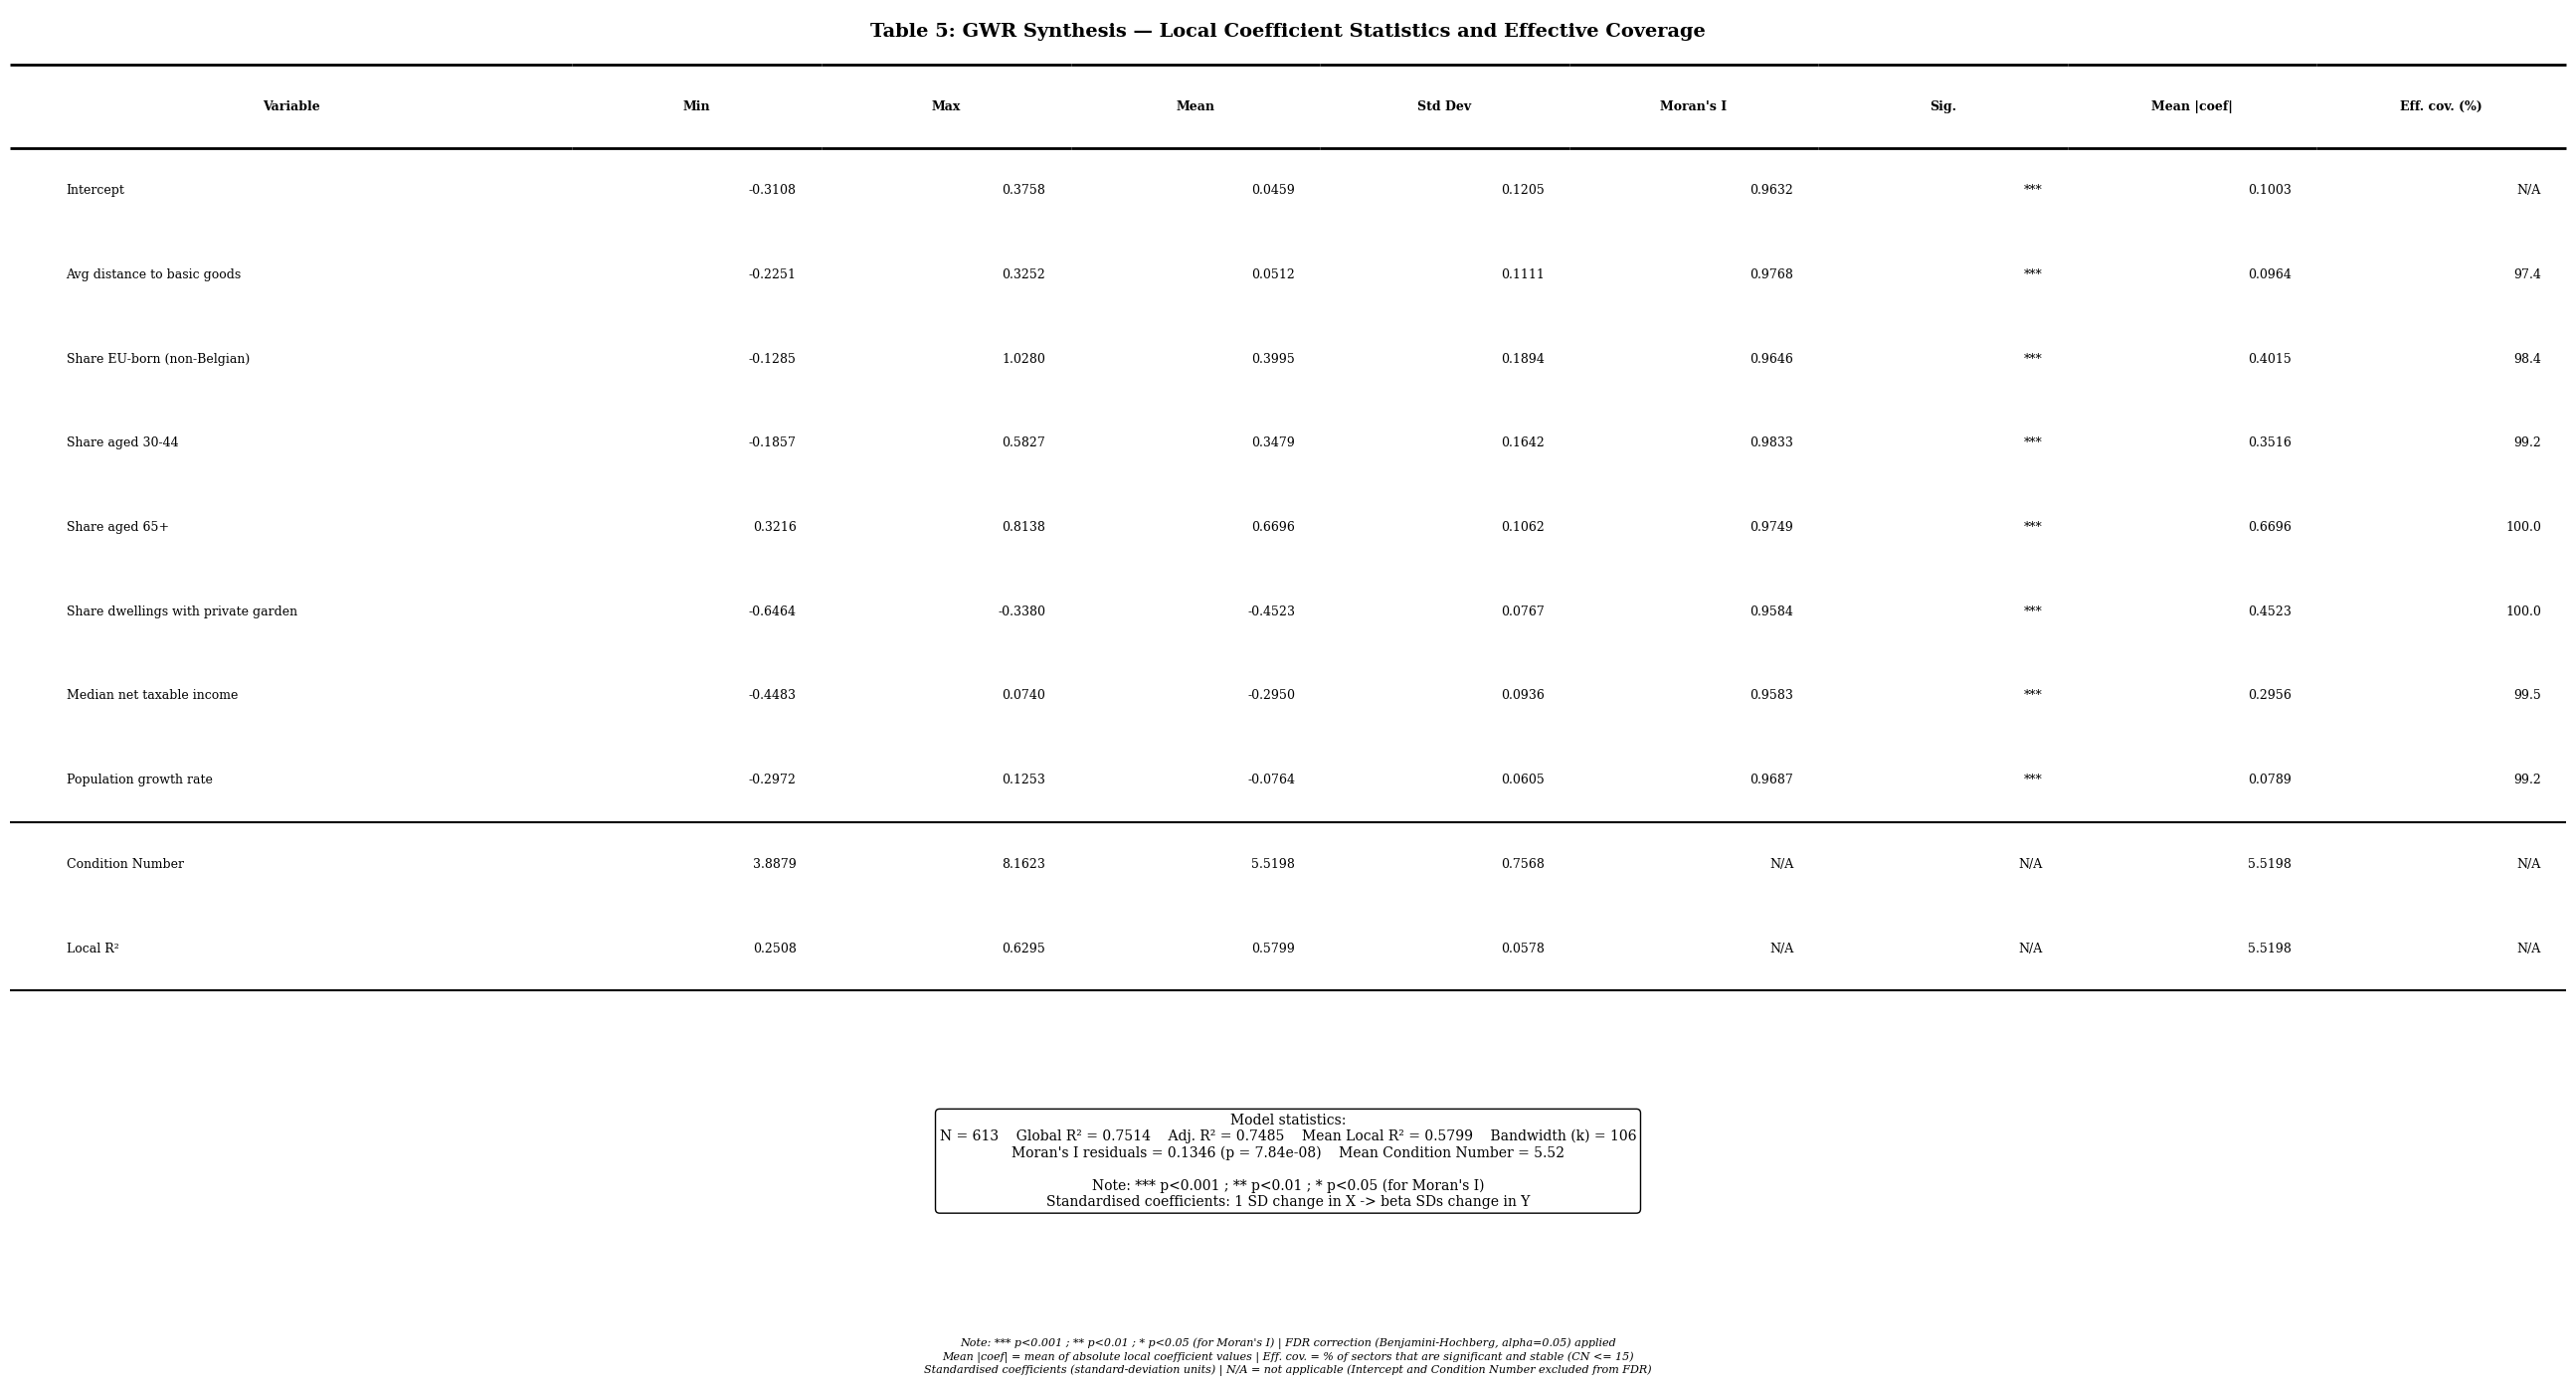

In [81]:
# ── Table 5: GWR Synthesis — Local Coefficients + Effective Coverage ─────

# Build coverage lookup from mask_stats
coverage_lookup = {ms['Variable']: ms['Pct_valid'] for ms in mask_stats}

tableau5_data = []

for i, (_, row) in enumerate(gwr_stats_df.iterrows()):
    var_name = row['Variable']
    var_label = VAR_LABELS_GWR.get(var_name, var_name)

    if i == 0:  # Intercept
        col_name = 'intercept'
        var_orig = None
    elif i <= n_vars:  # Independent variables
        var_orig = indep_vars[i - 1]
        col_name = f'coef_{var_orig}'
    else:  # Condition Number
        col_name = 'condition_number'
        var_orig = None

    # Mean absolute coefficient
    if col_name in gdf_gwr.columns:
        mean_abs_str = f"{np.nanmean(np.abs(gdf_gwr[col_name].values)):.4f}"
    else:
        mean_abs_str = 'N/A'

    # Effective coverage (significant & stable)
    if var_orig is not None and var_orig in coverage_lookup:
        couv_str = f"{coverage_lookup[var_orig]:.1f}"
    else:
        couv_str = 'N/A'

    # Moran's I significance
    moran_p = row['Moran p-value']
    moran_i_val = row["Moran's I"]
    if not np.isnan(moran_p):
        if moran_p < 0.001:
            sig = '***'
        elif moran_p < 0.01:
            sig = '**'
        elif moran_p < 0.05:
            sig = '*'
        else:
            sig = ''
    else:
        sig = 'N/A'

    tableau5_data.append({
        'Variable': var_label,
        'Min': f"{row['Min']:.4f}" if not np.isnan(row['Min']) else 'N/A',
        'Max': f"{row['Max']:.4f}" if not np.isnan(row['Max']) else 'N/A',
        'Mean': f"{row['Mean']:.4f}" if not np.isnan(row['Mean']) else 'N/A',
        'Std Dev': f"{row['Std']:.4f}" if not np.isnan(row['Std']) else 'N/A',
        "Moran's I": f'{moran_i_val:.4f}' if not np.isnan(moran_i_val) else 'N/A',
        'Sig.': sig,
        'Mean |coef|': mean_abs_str,
        'Eff. cov. (%)': couv_str,
    })

tableau5_df = pd.DataFrame(tableau5_data)

print('Table 5: GWR Synthesis — Local Coefficients + Effective Coverage')
print(tableau5_df.to_string(index=False))

csv_path = f'{OUT_DATA}/gwr_synthesis_table.csv'
tableau5_df.to_csv(csv_path, index=False)
print(f'\nTable 5 saved: {csv_path}')

# Publication-quality PNG
n_cols_t5 = len(tableau5_df.columns)
first_col_width = 0.22
other_col_width = (1.0 - first_col_width) / (n_cols_t5 - 1)
colWidths_t5 = [first_col_width] + [other_col_width] * (n_cols_t5 - 1)

fig = plt.figure(figsize=(26, 14))
ax = fig.add_subplot(111)
ax.axis('off')

table = ax.table(cellText=tableau5_df.values, colLabels=tableau5_df.columns,
                 cellLoc='left', loc='center', colWidths=colWidths_t5,
                 bbox=[0, 0.28, 1, 0.68])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 3.5)

for key, cell in table.get_celld().items():
    cell.set_linewidth(0)
    cell.set_edgecolor('black')
    cell.set_facecolor('white')
    cell.set_text_props(family='serif')

for j in range(n_cols_t5):
    cell = table[(0, j)]
    cell.set_text_props(weight='bold', family='serif', size=9, va='center')
    cell.set_facecolor('white')
    cell.visible_edges = 'TB'
    cell.set_linewidth(2.0)

for i in range(1, len(tableau5_df) + 1):
    for j in range(n_cols_t5):
        cell = table[(i, j)]
        cell.set_text_props(family='serif', size=9, va='center',
                            ha='left' if j == 0 else 'right')
        if j != 0:
            cell._loc = 'right'
        cell.visible_edges = ''

# Separator before condition number row
cn_row_t5 = len(tableau5_df) - 1
for j in range(n_cols_t5):
    cell = table[(cn_row_t5, j)]
    cell.visible_edges = 'T'
    cell.set_linewidth(1.5)

for j in range(n_cols_t5):
    cell = table[(len(tableau5_df), j)]
    cell.visible_edges = 'B'
    cell.set_linewidth(1.5)


# ── GWR Model Statistics Box ──────────────────────────────────────────────
ss_res_global = np.sum(local_resid ** 2)
ss_tot_global = np.sum((y - np.mean(y)) ** 2)
r2_global = 1 - (ss_res_global / ss_tot_global)
n = len(y)
p = X.shape[1]
r2_adj_global = 1 - (1 - r2_global) * (n - 1) / (n - p - 1)

w_stats = Queen.from_dataframe(gdf_gwr)
w_stats.transform = 'r'
moran_gwr = Moran(local_resid, w_stats)

stats_text = (
    f'Model statistics:\n'
    f'N = {n}    '
    f'Global R² = {r2_global:.4f}    '
    f'Adj. R² = {r2_adj_global:.4f}    '
    f'Mean Local R² = {np.nanmean(local_r2):.4f}    '
    f'Bandwidth (k) = {k_optimal}\n'
    f'Moran\'s I residuals = {moran_gwr.I:.4f} (p = {moran_gwr.p_norm:.2e})    '
    f'Mean Condition Number = {np.nanmean(local_cond_numbers[np.isfinite(local_cond_numbers)]):.2f}\n'
    f'\nNote: *** p<0.001 ; ** p<0.01 ; * p<0.05 (for Moran\'s I)\n'
    f'Standardised coefficients: 1 SD change in X -> beta SDs change in Y'
)

fig.text(0.5, 0.13, stats_text, ha='center', fontsize=10, family='serif',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', linewidth=1.0))

# ── Title and footnote ────────────────────────────────────────────────────
fig.text(0.5, 0.97,
         'Table 5: GWR Synthesis — Local Coefficient Statistics and Effective Coverage',
         ha='center', fontsize=14, fontweight='bold', family='serif')

note_text = (
    f"Note: *** p<0.001 ; ** p<0.01 ; * p<0.05 (for Moran's I) | "
    f"FDR correction (Benjamini-Hochberg, alpha={SIGNIFICANCE_LEVEL}) applied\n"
    f"Mean |coef| = mean of absolute local coefficient values | "
    f"Eff. cov. = % of sectors that are significant and stable (CN <= {CN_THRESHOLD})\n"
    f"Standardised coefficients (standard-deviation units) | "
    f"N/A = not applicable (Intercept and Condition Number excluded from FDR)"
)
fig.text(0.5, 0.01, note_text, ha='center', fontsize=8, style='italic', family='serif')

plt.tight_layout()
fig_path = f'{OUT_FIGURES}/gwr_synthesis_table.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f'Table 5 PNG saved: {fig_path}')


## Summary and Outputs

This notebook has completed a full geospatial regression analysis of isolation rates in Brussels statistical sectors. All outputs are saved in the `outputs/` directory.

### Generated Output Files

**Figures (`outputs/figures/`)**
| File | Description |
|------|-------------|
| `metrics_grid.png` | Grid of all input variable choropleth maps |
| `summary_statistics_table.png` | Table 1: Descriptive statistics (N, mean, std, min, max) |
| `correlation_matrix_all_variables.png` | Correlation heatmap for all variables |
| `ols_results_table.png` | Table 2: OLS regression coefficients and significance |
| `moran_tests_comparison.png` | Moran's I scatterplots (raw variable + OLS residuals) |
| `regression_diagnostics.png` | OLS diagnostic plots (residuals, Q-Q, histogram) |
| `gwr_local_r2.png` | Choropleth of GWR local R² |
| `gwr_local_coefficients.png` | Grid of local coefficient maps |
| `high_cn_areas_map.png` | Map of high condition number areas (CN > threshold) |
| `gwr_statistics_table.png` | Table 3: GWR coefficient statistics + Moran's I |
| `gwr_significance_summary_table.png` | Table 4: Local significance coverage summary |
| `gwr_synthesis_table.png` | Table 5: Full GWR synthesis table |

**Masked maps (`outputs/figures/masked_maps/`)**
- `masked_{variable}.png` — coefficient maps showing only significant & stable sectors

**Data (`outputs/data/`)**
| File | Description |
|------|-------------|
| `variable_summary_statistics.csv` | Descriptive statistics for all variables |
| `high_correlations.csv` | Variable pairs with \|r\| > 0.7 |
| `gwr_coefficients_statistics.csv` | Min, max, mean, std, Moran's I per coefficient |
| `gwr_significance_summary.csv` | Coverage % per variable (significant & stable) |
| `gwr_synthesis_table.csv` | Full Table 5 data |
| `high_cn_areas.csv` | Sectors with condition number above threshold |

**Spatial (`outputs/maps/`)**
| File | Description |
|------|-------------|
| `gwr_results.geojson` | GeoJSON with all GWR local coefficients and metadata |

### How to Cite

If you use or adapt this analysis, please credit the Brussels Perspective geodata portal (https://perspective.brussels) for the underlying data.

### Methodology References
- Benassi, F., & Iglesias-Pascual, R. (2025). A local regression approach to studying single-person households and social isolation in the main Spanish cities: a new pathway of socio-spatial polarization? Annals of Operations Research. https://doi.org/10.1007/s10479-025-06595-8
- Benjamini, Y., & Hochberg, Y. (1995). Controlling the false discovery Rate: A practical and powerful approach to multiple testing. Journal of the Royal Statistical Society Series B (Statistical Methodology), 57(1), 289–300. https://doi.org/10.1111/j.2517-6161.1995.tb02031.x
- Dormann, C. F., Elith, J., Bacher, S., Buchmann, C., Carl, G., Carré, G., Marquéz, J. R. G., Gruber, B., Lafourcade, B., Leitão, P. J., Münkemüller, T., McClean, C., Osborne, P. E., Reineking, B., Schröder, B., Skidmore, A. K., Zurell, D., & Lautenbach, S. (2012). Collinearity: a review of methods to deal with it and a simulation study evaluating their performance. Ecography, 36(1), 27–46. https://doi.org/10.1111/j.1600-0587.2012.07348.x
- Fotheringham, A. S., Brunsdon, C., & Charlton, M. (2003). Geographically weighted regression: The analysis
of spatially varying relationships. John Wiley & Sons.
